# Методы машинного обучения в предсказании ВР
### [Coloab](https://colab.research.google.com/github/MVRonkin/TimeSeriesCourse/blob/main/Last/WS/06-MLForecast.ipynb)

In [1]:
import os
UPDATE_UTILITS = True
if UPDATE_UTILITS:
    !rm -rf utilits4tsc temp_repo
    !git clone --depth 1 https://github.com/MVRonkin/utilits4tsc.git utilits4tsc
    

"rm" ­Ґ пў«пҐвбп ў­гваҐ­­Ґ© Ё«Ё ў­Ґи­Ґ©
Є®¬ ­¤®©, ЁбЇ®«­пҐ¬®© Їа®Ја ¬¬®© Ё«Ё Ї ЄҐв­л¬ д ©«®¬.
fatal: destination path 'utilits4tsc' already exists and is not an empty directory.


In [2]:
from utilits4tsc import *
plt_style_GOST()

In [3]:
from IPython.display import display, Markdown
display(Markdown(generate_toc(max_lvl=2)))

## Содержание
* [Методы машинного обучения в предсказании ВР](#методы-машинного-обучения-в-предсказании-вр)
  * [Основные материалы к работе](#основные-материалы-к-работе)
  * [Знакомство с `MLForecast`](#знакомство-с-mlforecast)
  * [Работа с признаками](#работа-с-признаками)
  * [Обучение модели `MLForecast`](#обучение-модели-mlforecast)
  * [Интерпретация признаков](#интерпретация-признаков)
  * [Дополнительно](#дополнительно)

<!-- ## Редукция временных рядов к структурированным данным -->

## Основные материалы к работе

### Темы в работе

|раздел | [nixtla](https://nixtlaverse.nixtla.io/mlforecast/) | [FPPPY](https://otexts.com/fpppy/)|
|-------|-----------------------|------|
|MLForecast | [mlforecast](https://nixtlaverse.nixtla.io/mlforecast/index.html) |[7.1](https://otexts.com/fpppy/nbs/07-regression.html#sec-regression-intro) |

### Дополнительня литература
* [10.2 Временные ряды - прогноз сведением к задаче регрессии Yandex ml handbook](https://education.yandex.ru/handbook/ml/article/vremennye-ryady)
* [Automated Time Series Feature Engineering with MLforecast](https://www.nixtla.io/blog/automated-time-series-feature-engineering-with-mlforecast)
* Forecastegy ml forecast: [scikit-learn](https://forecastegy.com/posts/multiple-time-series-forecasting-with-scikit-learn/), [xgboost](https://forecastegy.com/posts/multiple-time-series-forecasting-with-xgboost-in-python/), [multivariate ts](https://forecastegy.com/posts/multivariate-time-series-forecasting-in-python/)
* [How-to-mlforecast](https://levelup.gitconnected.com/how-to-mlforecast-your-time-series-data-c583283e0c28)
* [m4-competition-cv](https://www.kaggle.com/code/lemuz90/m4-competition-cv)
* [skforecast ml forecast introduction GitHub](https://github.com/skforecast/skforecast/blob/master/docs/introduction-forecasting/introduction-forecasting.md)

### Аналогичные библиотеки
* [sktime](https://www.sktime.net/en/stable/)
* [skforecast](https://skforecast.org/)

### Цели редукции

#### Почему на практике используют ML

 __Недостатки__ моделей [`SARIMA`](https://sherbold.github.io/intro-to-data-science/09_Time-Series-Analysis.html) являются :
* сложность предварительного анализа и подготовки данных. 
* необходимость частого переобучения. 
* трудно настраиваемы параметры моделей.
  
[__На практике бывает проще__](https://mlcourse.ai/book/topic09/topic9_part1_time_series_python.html#linear-and-not-only-models-for-time-series) 
* выбрать несколько признаков из имеющегося временного ряда и построить регрессионную модель.

> ML-based подход не подкреплен теорией и нарушает ряд предположений (например, теорему Гаусса-Маркова, особенно для некоррелированных ошибок), но он очень полезен на практике и часто используется в соревнованиях по машинному обучению.

<!-- <img src="https://www.vanenburg.com/wp-content/uploads/2022/05/MLOps-lifecycle-1-1024x940.png" width="400px"> -->

#### Прогнозирование временных рядов ≠ регрессия (scikit-learn)


ML для предсказания ВР сводится к составлнию [таблицы](https://cienciadedatos.net/documentos/py27-time-series-forecasting-python-scikitlearn.html) -  редукции ВР. То есть путем прохождени окна по ВР так, что следующее за окном значение всегда будет меткой.

<img src='https://raw.githubusercontent.com/cerlymarco/tspiral/master/imgs/direct.PNG'>

Разная природа данных:

- Регрессия:
    - Предсказание метки  по независимым признакам.
    - Строки таблицы можно перемешивать без потери смысла.

- Прогнозирование ВР:
     - Предсказание будущего этой же переменной по её прошлому.
     - Данные строго последовательны (каузальность), перемешивание разрушает задачу.

Типичные ошибки при наивном сведении  ВР к таблице:
- Ложный оптимизм: Случайные корреляции между далекими точками ряда (при использовании широких окон) дают отличную оценку на тесте, но модель «сломана» и не работает в реале.
- P-value hacking / Утечка данных: Неправильное скользящее окно приводит к тому, что будущее «подглядывает» в прошлое. Решение: строгая последовательная кросс-валидация.
 - Потеря каузальности: предсказание от регрессора,  нужно правильно «развернуть» обратно в прогноз, соблюдая временные лаги (что и когда было известно модели).

<!-- Строго говоря __прогнозирование ВР__ - это не то же самое, что контролируемое обучение, в т.ч. задача регрессии, привычная для пользователей, например, `scikit-learn`. Несмотря на то, что прогнозирование может быть “решено” с помощью алгоритмов регрессии это лишь косвенно связанные процессы, замещение которых требует тщательного планирования.  Дело в том, что задача регрессии предполагает предсказание метки по набору признаков, не связанных с ней на прямую. В тоже время в задаче предсказания будущие значения одной и той же переменной предсказывается по ее предыдущим значениям. Более в задаче регрессии предполагается модальность «таблица», в которой записи (строки) могут быть перемешаны в любом порядке. В задаче предсказания такая операция нарушила бы казуальность – то есть последовательность данных и всю, связанную с этим информацию. 
При этом тут может быть два подхода. С одной стороны, задача регрессии может быть сведена к задаче предсказания. С другой стороны, сама по себе задача предсказания может быть сведена к задаче табличной регрессии. 
В контролируемой регрессии мы предсказываем метки/целевые переменные на основе переменных признаков
Типичными ошибками/«подводными камнями» при наивном сопоставлении задач регрессии и предсказания могут быть следующие:
* Чрезмерно оптимистичная оценка производительности, которая может быть связана с появлением ложных корреляций между данными, которые в свою очередь во временном ряду были бы значительно разнесены во времени. Точно также следует принять во внимание необходимость исключительно последовательно разделения на тренировку и тест в [задачах предсказания](https://www.aeon-toolkit.org/en/latest/examples/forecasting/forecasting_sklearn.html#Pitfall-1:-over-optimism-in-performance-evaluation,-false-confidence-in-%22broken%22-forecasters).
* Черезмерное использование окон (окон длинного размера и стратегий окон) для временных рядов и их сведения к задаче регрессии может привести к т.н. [“p-value hacking”](https://www.aeon-toolkit.org/en/latest/examples/forecasting/forecasting_sklearn.html#Pitfall-2:-obscure-data-manipulations,-brittle-boilerplate-code-to-apply-regressors) – то есть утечке информации (или появление ложных зависимостей).  Отметим, что во избежание такого эффекта тесты на преобразованных данных должны проверяться для нескольких сегментов ВР. То есть нужна кросс валидация.  Кроме того, в статистике есть [несколько тестов](https://embassy.science/wiki/Theme:6b584d4e-2c9d-4e27-b370-5fbdb983ab46) на ложные корреляции. Например Bonferonni correction, Scheffé's method и false discovery rate. 
* При составлении прогнозов по резульаттам табличных регрессий выходные данные контролируемого регрессора должны быть преобразованы обратно в прогнозы. [Это легко забывается](https://www.aeon-toolkit.org/en/latest/examples/forecasting/forecasting_sklearn.html#Pitfall-3:-Given-a-fitted-regression-algorithm,-how-can-we-generate-forecasts?) и приводит к ошибкам в прогнозах и оценке (особенно, если кто-то не отслеживает, какие данные известны в какое время, или как инвертировать преобразование, выполненное при подгонке). -->


### Стратегии редукции

#### Простые стратегии

<!-- <img src="https://cienciadedatos.net/images/transform_timeseries.gif" width="900px"> -->

<!-- 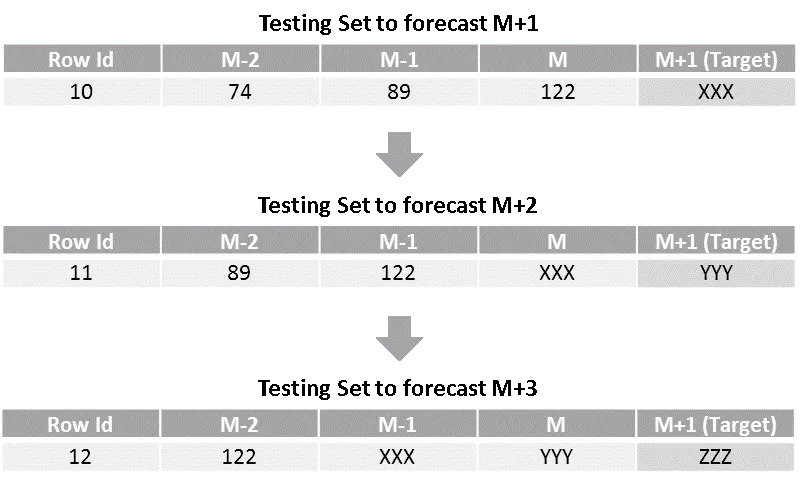  -->

Если требуется предсказание по несколько значний в будущем, то наивное использование обозначенной стратегии приводит к появлению ряда затруднейний. Эти затруднения могут быть сняты путем:
* [__Рекурсивное предсказание__](https://cienciadedatos.net/documentos/py27-time-series-forecasting-python-scikitlearn.html#Recursive-multi-step-forecasting) (`recursive strategy`) в котором предсказание будущих значений с лагом выше 1 строится по результатам предыдущих предсказанных значений.  Этот метод также может быть назван итеративным.
<!-- <img src="https://cienciadedatos.net/images/diagram-recursive-mutistep-forecasting.png" width="700px">
-->
<!-- 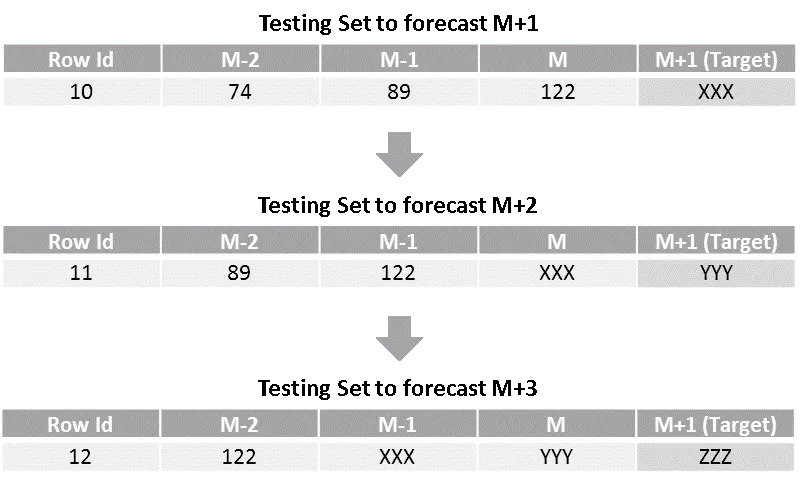
-->
<img src="https://yastatic.net/s3/education-portal/media/recursive_8427cc778b_923a246e65.webp" width="700px">

* [__Прямое предсказание__](https://cienciadedatos.net/documentos/py27-time-series-forecasting-python-scikitlearn.html#Direct-multi-step-forecasting) (`direct strategy`) в котором моделируется ситуация табличных данных с несколькими метками или регрессия может быть проведена для нескольких таблиц. В том числе [разными методами для разных таблиц](https://machinelearningmastery.com/multi-step-time-series-forecasting/)! 
<!-- <img src="https://cienciadedatos.net/images/diagram-direct-multi-step-forecasting.png" width="700px"> -->

<img src="https://yastatic.net/s3/education-portal/media/direct_7ff22dabcb_ba7c98a644.webp" width="700px">


#### Продвинутые стратегии

* [__Предсказание последовательности__](https://cienciadedatos.net/documentos/py27-time-series-forecasting-python-scikitlearn.html#Multiple-output-forecasting) (`Multiple output strategy`) - стратегия, доступная лишь в некоторых моделях типа [<tt>LSTM</tt>](https://neptune.ai/blog/arima-vs-prophet-vs-lstm) в режиме <tt> sequence 2 sequence </tt>.

* Отметимт, что может также быть и <tt>комбинированное</tt> [прямое-рекурсивное предсказание](https://machinelearningmastery.com/multi-step-time-series-forecasting/). Например, если результаты предсказания одной из таблиц используются как дополнительные факторы во второй. Могут быть предуманы [и другие стратегии](https://link.springer.com/chapter/10.1007/978-3-642-36318-4_3).

При этом все подходы могту иметь и [свои достоинства и свои недостатки](https://netman.aiops.org/~peidan/ANM2019/5.KPIAnomalyDetection/ReadingLists/time_series.pdf). Например рекурсивные модели могту иметь деградацию свойств для длинных горизонтов прогнозирования. Однако, модели с прямым предсказанием потребует слишьком много предсказателей По одному на каждый шаг). Комбинированная модель от части вбирает как достоинства так и недостатки обобих подходов. Иногда также используется модель с несклькими выходами (`MIMO`). Однако точность такой модели для каждого предсказания может быть ниже, чем для отдельных моделей.

   
>Отметим, что в некоторых случаях могут быть и более продвинутые стратегии, например, модель [<tt>DeepAR</tt>](https://arxiv.org/abs/1704.04110) используется подход "как бы" прямого предсказания на этапе обучения и рекурсивную стратегию на этапе работы. Другими словами на этапе обучения предсказанные лаги заменяются на их метки. Такая стратегия также называется гибридной.
><img src="https://ars.els-cdn.com/content/image/1-s2.0-S0169207019301888-gr3_lrg.jpg" width="700px">\
> В наиболее сложных ВР могут также использоваться продвинутые [стратегии предсказаний](https://netman.aiops.org/~peidan/ANM2019/5.KPIAnomalyDetection/ReadingLists/time_series.pdf). Часто  с использованием нескольких различных моделей. Например, локальные модели, могут использоваться для отдельных участков ВР. При этом для кажого участка модель может оперделяться методом `backtesting`. Также могут использоваться ансамбли моделей или последовательности, когда каждая следующая модель работает с результатом предыдущей (образую бустинг моделей).

### Импорт

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [17]:
from sklearn.neighbors import KNeighborsRegressor
import lightgbm as lgb
from xgboost import XGBRegressor

In [18]:
import warnings
warnings.filterwarnings('once')

In [19]:
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from mlforecast.utils import PredictionIntervals

In [20]:
from mlforecast.target_transforms import LocalStandardScaler

In [21]:
from functools import partial

In [22]:
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

### Загрузка данных

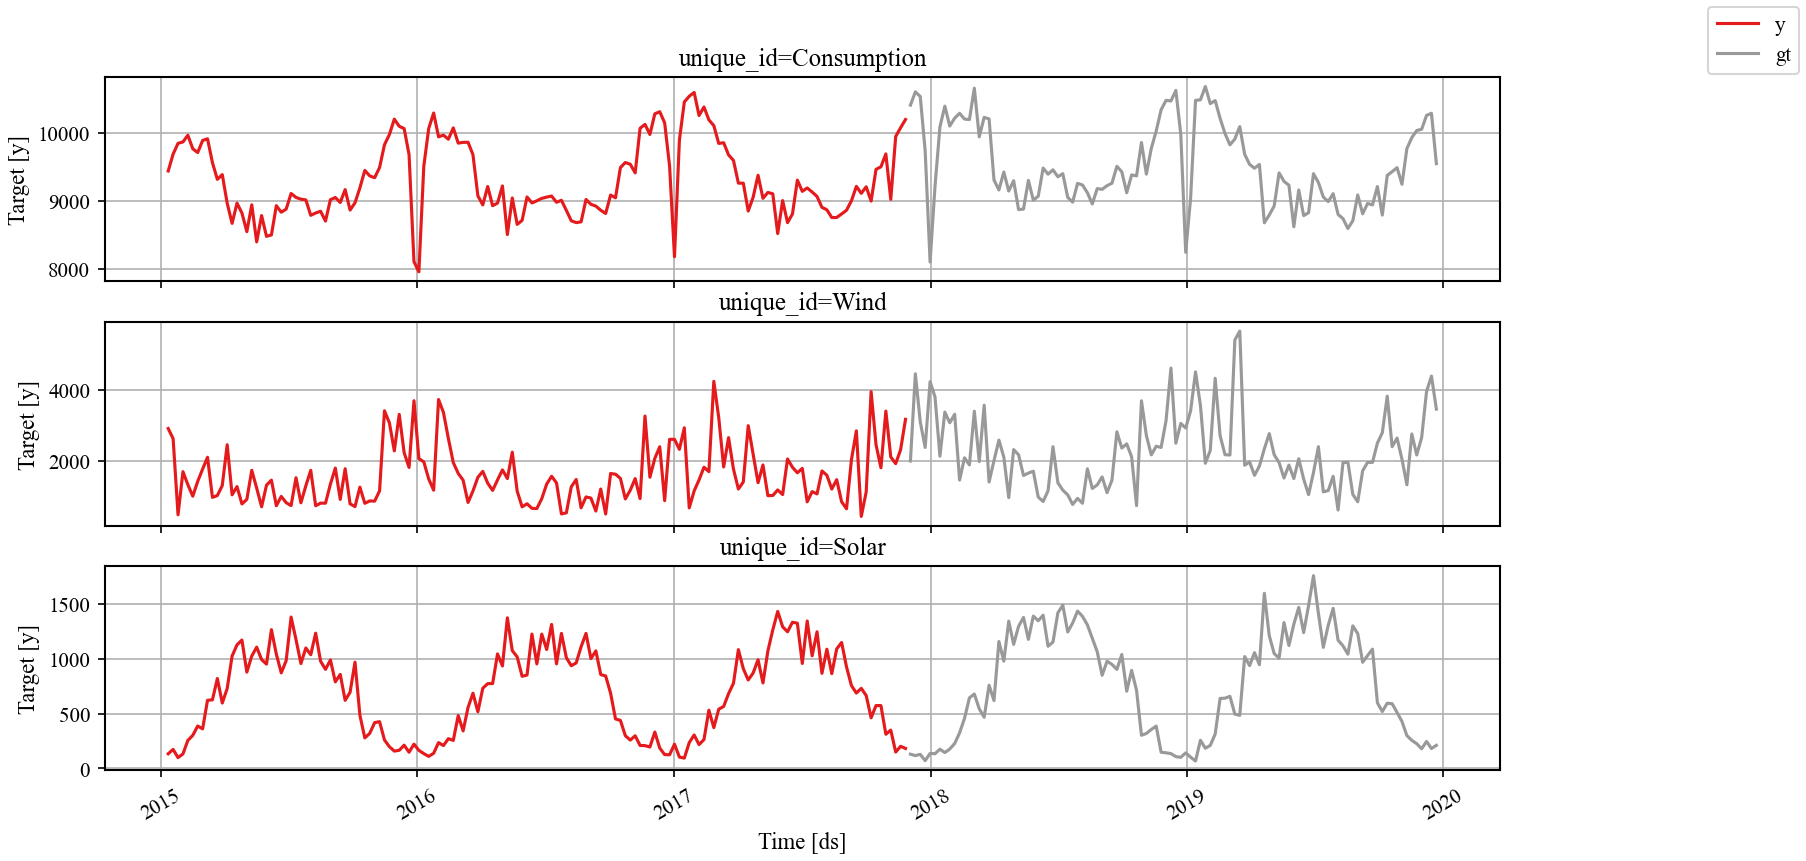

In [24]:
df= pd.read_csv(os.path.join( "utilits4tsc",
            "OPDS_DE_EDA.csv"),
    parse_dates=["time"],
    index_col="time"
)
df.head(1)



ts = ['Consumption','Wind',	'Solar']
base_cols = ['unique_id', 'ds', 'y']
exog_cols = ['temperature','radiation_direct_horizontal']

y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]


date_index = y.index
panel_list = [
    pd.DataFrame({
        'ds': date_index,
        'y': y[t].values,
        'unique_id': t,
        # Добавляем внешние переменные из y:
        'temperature': y['temperature'].values,
        'radiation_direct_horizontal': y['radiation_direct_horizontal'].values
    }) 
    for t in ts
]

panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols + exog_cols] # Теперь это сработает

panel_df.sample(5)

FREQ = y.index.freq


SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)


df_test_exdogs  = panel_df[base_cols+exog_cols].groupby("unique_id").tail(FH)
df_train_exdogs = panel_df[base_cols+exog_cols].drop(df_test.index).reset_index(drop=True)

X_test  = df_test_exdogs.drop(columns = 'y')

plot_series_v2(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1', n_cols = 1)

In [25]:
metric_map = {
    'mase': partial(mase, seasonality=SEASON),
    'mae': mae,
    'rmse': rmse,
    'smape': smape,
    # 'CPSR':scaled_crps,
    # 'CI':coverage,
    # 'SQL':partial(scaled_quantile_loss, seasonality=SEASON),
}
metrics = list(metric_map.values())
metric_names = list(metric_map.keys())

##  Знакомство с `MLForecast`

### Библиотека `MLForecast`

В данной работе мы изучим возможности фреймворка [`mlforecast`](https://nixtlaverse.nixtla.io/mlforecast/index.html) для предсказания ВР с использованием методов машинного обучения от компании [<tt>nixtla</tt>](https://nixtlaverse.nixtla.io/).

Библиотека [__`MLForecast`__](https://nixtlaverse.nixtla.io/mlforecast/index.html) - это бибилиотека, призванная обеспечить автоматическое создание признаков для прогнозирования временных рядов, облегчая использование глобальных моделей машинного обучения. Библиотека рассчитана на высокую производительность и масштабируемость. Библиотека относится к общей [экосистеме компании Nixtla](https://nixtlaverse.nixtla.io/neuralforecast/examples/statsmlneuralmethods.html). 

<!-- __Ключевые особенности MLForecast__ включают: -->
<!-- * Поддержка моделей `sklearn` -->
<!--  :MLForecast совместим с моделями, использующими `API` `scikit-learn`. Это делает его очень гибким и позволяет легко интегрироваться с широким спектром алгоритмов машинного обучения. -->
<!-- * Простота: С помощью `MLForecast` задачи обучения, прогнозирования и бэктестинга моделей решаются всего в нескольких строках кода. Такая простота делает его удобным для практиков любого уровня квалификации. -->
* Оптимизация для скорости: `MLForecast` разработан для быстрого выполнения задач, что очень важно при работе с большими массивами данных и сложными моделями.
* Горизонтальная масштабируемость: `MLForecast` способен к горизонтальному масштабированию с использованием таких фреймворков распределенных вычислений, как `Spark`, `Dask` и `Ray`. Эта особенность позволяет эффективно обрабатывать огромные массивы данных, распределяя вычисления по нескольким узлам кластера, что делает его идеальным для решения масштабных задач прогнозирования временных рядов.



<blockquote>
    
Отметим также, что использование методов МО в предсказании ВР может быть реализовано и в фреймворках:
* [`sktime`](https://www.sktime.net/en/latest/examples/01_forecasting.html#3.-Advanced-composition-patterns---pipelines,-reduction,-autoML,-and-more) при помощи функционала [`make_reduction`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.compose.make_reduction.html) или отдельных классов. А также почти полный аналог в [`aeon`](https://www.aeon-toolkit.org/en/stable/examples/forecasting/forecasting.html#3.1-Reduction:-from-forecasting-to-regression).
* [`skforecast`](https://skforecast.org/0.11.0/index.html)  адаптированного фреймворка для использования методов [машииного обучения в задачах авторегрессионного предсказания временных рядов](https://cienciadedatos.net/documentos/py27-time-series-forecasting-python-scikitlearn.html). Однако это устаревший фреймворк.
* [`sklearn`](https://scikit-learn.org/stable/auto_examples/applications/plot_time_series_lagged_features.html) в связке с [`pandas`](https://pandas.pydata.org/docs/getting_started/intro_tutorials/09_timeseries.html) также предоставляет некоторый встроенный функционал для работы с [<tt>лаговыми признаками</tt>](https://mlcourse.ai/book/topic09/topic9_part1_time_series_python.html#time-series-lags) и [<tt>временными рядами в целом</tt>](https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html#).  
* и другие библиотеки. 

<!-- Среди указанных `MLForecast` - это мощная библиотека, которая обеспечивает автоматическое создание признаков для прогнозирования временных рядов, облегчая использование  моделей машинного обучения. Она рассчитана на высокую производительность и масштабируемость. -->




### Объект MLForecast

#### MLForecast  fit

<!-- Основным классом библиотеки явялется [`MLForecast`](https://nixtlaverse.nixtla.io/mlforecast/forecast.html). Он позволяет достаточно гибко строить пайплайны и тестировать модели предсказания. Объекет по сути создает таблицу, реализующую рекурсивный авторегрессионный процесс.  -->

<!-- В самом простом случае  -->
Оъект [`MLForecast`](https://nixtlaverse.nixtla.io/mlforecast/forecast.html) задается через:
*  `models` - объявление моделей машинного обучения c scikit-learn api.
* объявление частоты - временного шага `freq`.
* выбранные временные шаги `lags`. Эта переменная задает окно или его составляющие для ВР. Например может быть задан массив до 52 шага или могу быть также выбраны и отдельные лаги.
* `target_transforms` - преобразование целевой переменной.
* 
<!-- Для визуализации полученной таблицы мы можем использовать метод `MLForecast.preprocess`.   -->

>Напомним, что [_лаги_](https://forecastegy.com/posts/multiple-time-series-forecasting-with-scikit-learn/#lags) - это просто прошлые значения временного ряда, которые вы сдвигаете вперед, чтобы использовать их в качестве признаков в модели. Интуицаия тут следующая. 
Например, если вы хотите предсказать спрос на товар на следующей неделе, вы можете использовать в качестве признака спрос в тот же будний день на предыдущей неделе.

Вспомним что ВР имеют сильное влияние сезонности. Поэтому мы можем произвести численное дифференцирование помощью трансформатора `mlforecast.target_transforms.Differences`, который мы передаем через `target_transforms`. 

Для знакомства с фреймворком попробуем запустить линейную модель регрессии (`LinearRegression()`) из пакета `sklearn`.

In [26]:
fcst = MLForecast(
    models=LinearRegression(),
    freq=FREQ,  # our serie has a monthly frequency
    lags=[1,2,3, 52],    
    target_transforms=[Differences([52])],   
)


Количество и выбор лагов можно произвести по значемым отсчетам АКФ (или даже ЧАКФ)!

Анализ что класть - это анализ DS-Временного ряда

#### MLForecast  fit - predict

__Обратите внимание__ в `MLForecast` не предусмотрен метод `forecast`

In [28]:
fcst.fit(df_train, )

MLForecast(models=[LinearRegression], freq=<Week: weekday=6>, lag_features=['lag1', 'lag2', 'lag3', 'lag52'], date_features=[], num_threads=1)

In [29]:
fcst_sf = fcst.predict(h=FH,  )

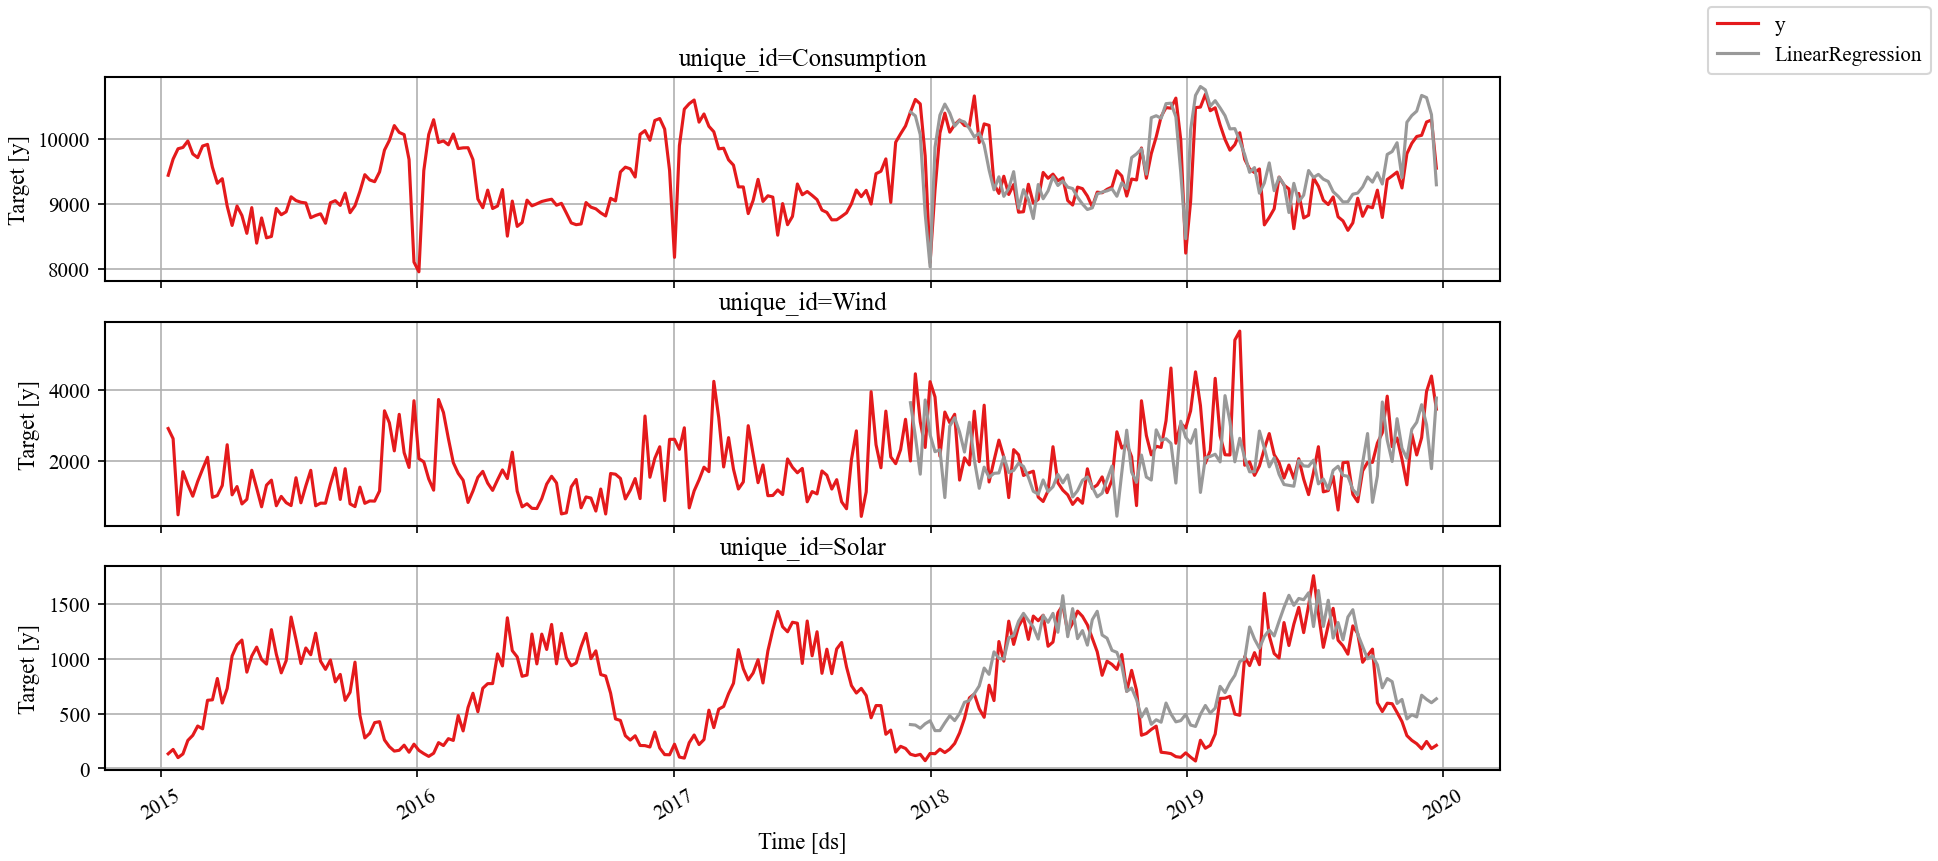

In [30]:
evaluate_and_plot(df_train,
                  df_test,
                  forecasts_or_eval = fcst_sf,
                  metrics = metrics,
                 )

#### MLForecast preprocessing

Пред продолжение знакомства с библиотекой проверим то, как выглядит наша таблица. Эта процедура может быть проведена с результатом в виде таблицы, в которой помимо исходных столбцов (`unique_id`, `ds`, `y`) добавлены рассчитанные признаки `lag_features`. Кроме того столбец `y` преобразован в соотвествии с `target_transforms`.

> Отметим, что [очень важно проверить](https://forecastegy.com/posts/multiple-time-series-forecasting-with-scikit-learn/#checking-for-data-leakage-in-features), правильно ли были вычислены характеристики, нет без утечки данных (например, использование цели в числе лага).

In [34]:
prep = fcst.preprocess(df_train)
prep.head(3)

,unique_id,ds,y,lag1,lag2,lag3,lag52
104,Consumption,2017-01-08,384.340,222.176,1406.657,466.986,71.239
105,Consumption,2017-01-15,389.718,384.340,222.176,1406.657,376.527
106,Consumption,2017-01-22,246.380,389.718,384.340,222.176,445.910


Проверим что таргет и лаги по производным 

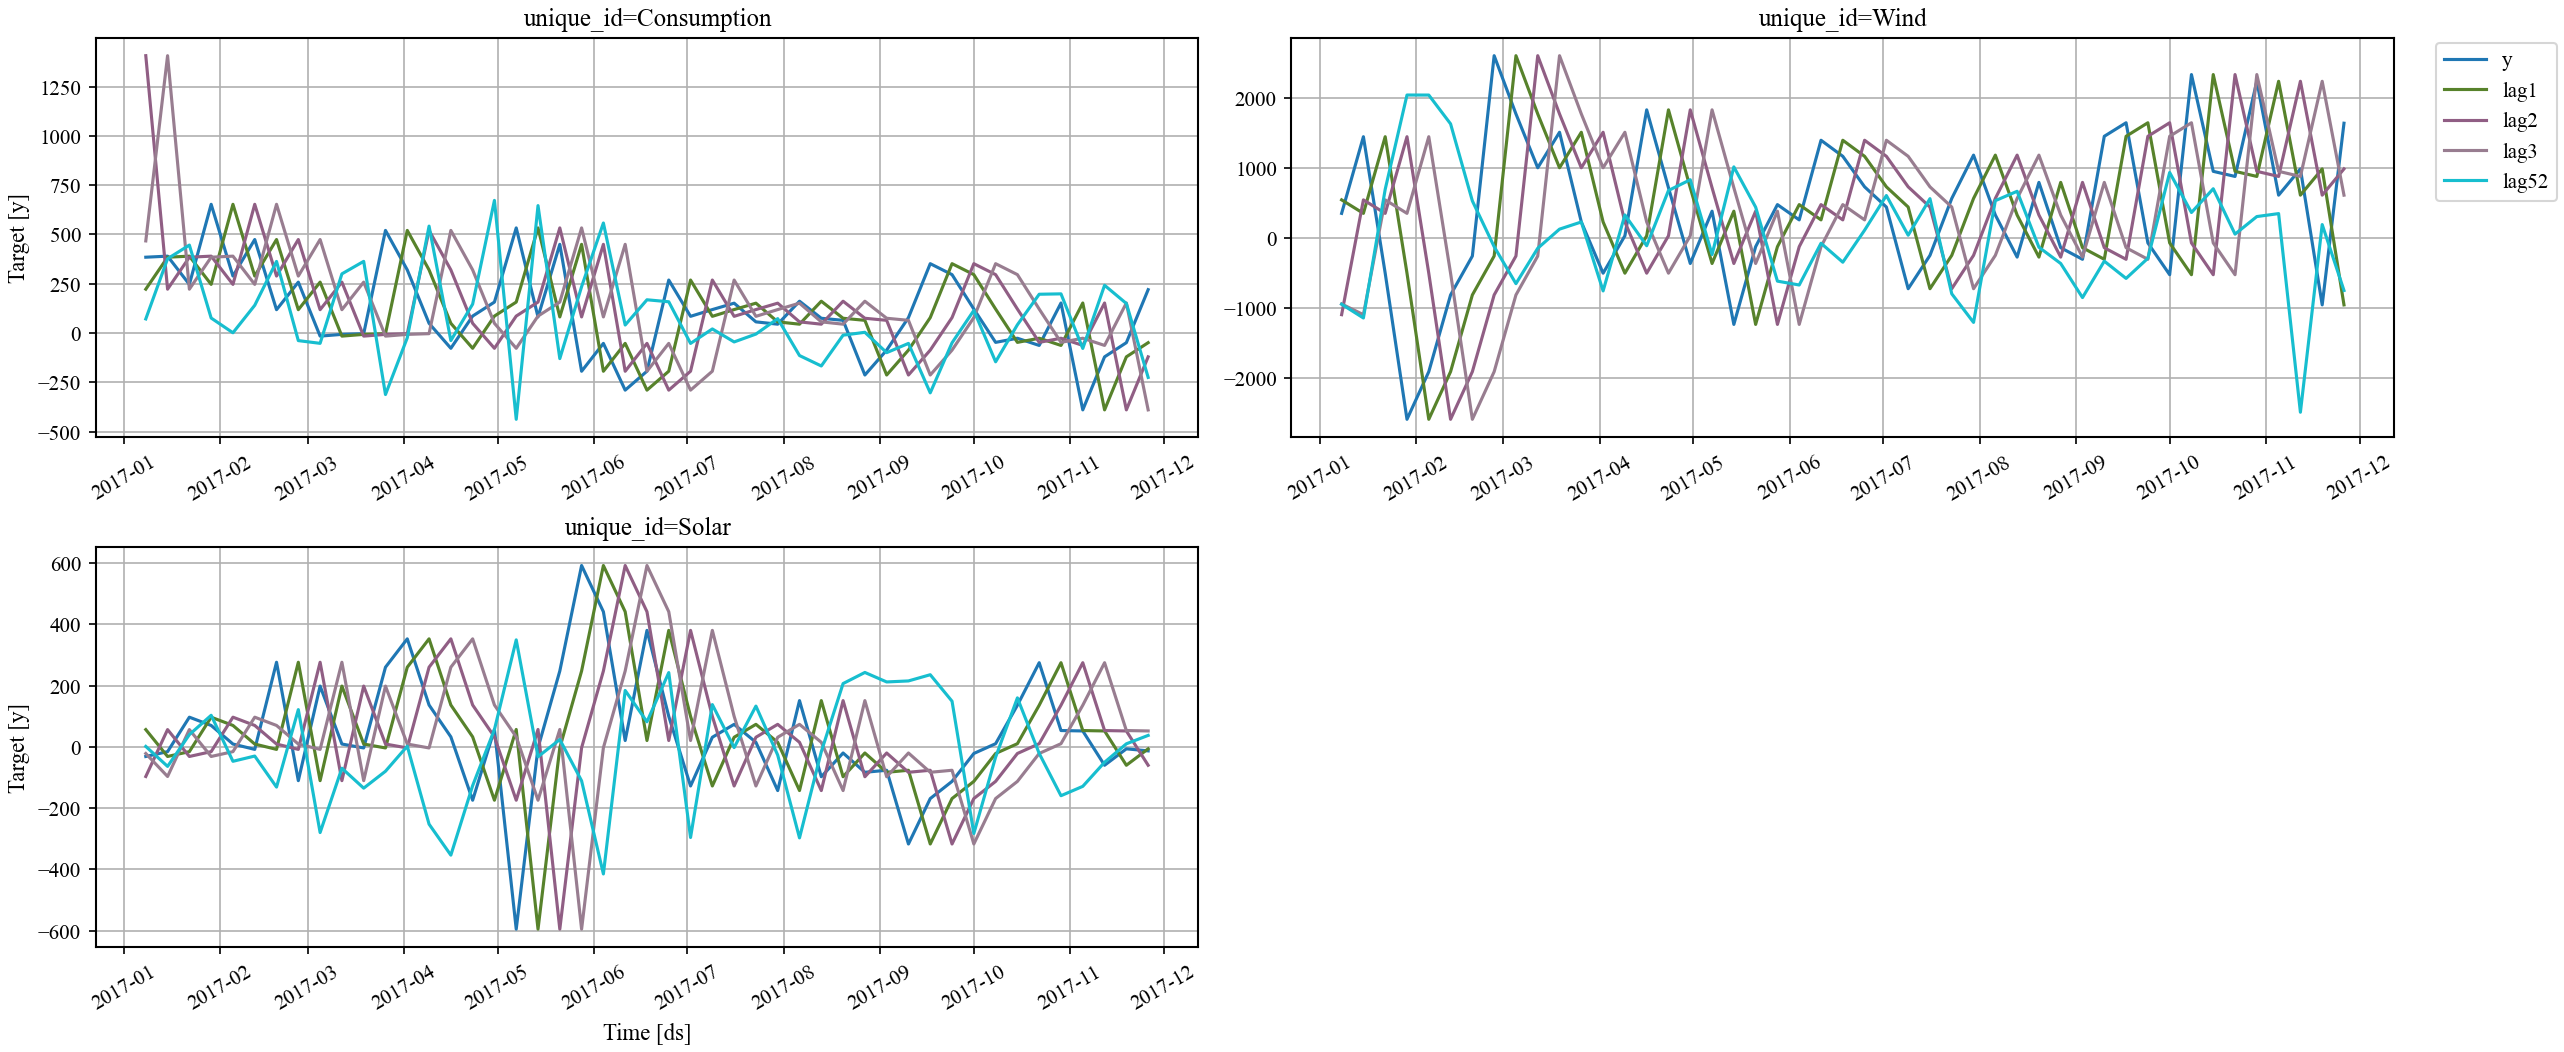

In [37]:
plot_series(forecasts_df=prep)

Полученная таблица может быть исследована классическими методами машинного обучения. Например посмотрим на корреляцию признаков.

In [32]:
prep.drop(columns=['unique_id', 'ds']).corr()['y']

y        1.000000
lag1     0.356151
lag2     0.067252
lag3    -0.043438
lag52   -0.487001
Name: y, dtype: float64

## Работа с признаками

### Типы признаков для временных рядов  в `mlforecast`

В [<tt>mlforecast</tt>](https://nixtlaverse.nixtla.io/mlforecast/index.html) имеется возможность гибкого создания пайплайнов обработки признаков  редуцированой таблицы:
* __`target_transforms`__ - [преобразования меток](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/target_transforms_guide.html), например,
    *  встроенные преобразование `mlforecast.target_transforms`, типа Бокса-Кокса или дифференцирование,
    *  преобразования `sklearn` если они не требуют обучения, задаются через [`GlobalSklearnTransformer`](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/target_transforms_guide.html#globalsklearntransformer) 
    *   или [преобразования, описаны самостоятельно](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/target_transforms_guide.html#custom-transformations).
<!-- * Также могут быть использованы стандартные преобразования пакета `sklearn` если они не требуют обучения. Например, логорифмирование. Для этого используется wrapper  -->
* __`lags`__: используем $1, 2, 3, 52$-й, лаги, которые передаются в виде списка.
    <!-- * Отметим, что потенциально вы можете передать диапазон `range` вместо листа. -->
* __`lag_transforms`__ - словарь, ключи - номера лагов, а значениями - [списки преобразований](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/lag_transforms_guide.html), которые мы хотим применить к этому запаздыванию.
    <!-- * Преобрзования могут быть получены из стандартных модуля `mlforecast.lag_transforms`, либо функциями [`numba` `jitted`](https://numba.pydata.org/) (чтобы вычисление функций не стало узким местом и мы могли обойти `GIL` при использовании многопоточности). В том числе мы попробуем подходящую для такой демонстрации утилиту [`window_ops`](https://jmoralez.github.io/window_ops), ускоряющую стандартный [оконный функионал Pandas](https://pandas.pydata.org/docs/user_guide/window.html). Отметим, что преобразования могут комбинироваться при помощи класса [`Combine`](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/lag_transforms_guide.html#extending-the-built-in-transformations). -->
* __`date_features`__: временные метки.
* другие [экзогенные признаки](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/exogenous_features.html) 
<!-- *  Это можно сделать, передав список строк с компонентами [`pandas time/date components`](https://pandas.pydata.org/docs/user_guide/timeseries.html). Вы также можете передавать [самостоятельно сформированные функции, которые будут принимать столбец времени в качестве входных данных](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/custom_date_features.html). Функционал для этого может быть сформирован [специальными средствами Pandas](https://pandas.pydata.org/docs/user_guide/timeseries.html) или могут быть функции, созданные при [помощи сторонних утилит](https://khuyentran1401.github.io/Efficient_Python_tricks_and_tools_for_data_scientists/Chapter5/time_series.html), например создающие признаки [выходных дней](https://python-holidays.readthedocs.io/en/latest/). Мы создадим [функцию создающую признак конец года](https://pandas.pydata.org/pandas-docs/stable/reference/offset_frequency.html)  как пример. -->

<!-- > [Важно указать](https://forecastegy.com/posts/multivariate-time-series-forecasting-in-python/), что при построение таблиц признаков с экзогенными факторами во временных рядах следует разделять 
>* __Динамические признаки__ - это те, которые изменяются со временем и будут известны в будущем.
>* __Cтатические признаки__ - те, что е меняются со временем.
>  
> Например, значение `date_features` будет определенно известно в будущем, в тоже время значение, например, температуры вероятно не будет известно.  Для таких случаев в `MLForecast` будет повторять первое значение каждого статического признака для всех временных отметок, которые вы хотите предсказать.  -->

>[При формировании признаковых пространств](https://netman.aiops.org/~peidan/ANM2019/5.KPIAnomalyDetection/ReadingLists/time_series.pdf) важно понимать, что
>* при слишьком большом признковом пространстве модели могут ухудшать качество прогноза. [Особенно для малых выборок](https://journalofbigdata.springeropen.com/articles/10.1186/s40537-023-00727-2).
>* При выборе [пространств признаков](https://machinelearningmastery.com/feature-selection-time-series-forecasting-python/) должны быть использованы  [методы отбора признаков](https://scikit-learn.org/stable/modules/feature_selection.html). Как миниму признаки должны [проверяться на корреляционные зависимости](https://www.researchgate.net/publication/272668319_Feature_Selection_for_Time_Series_Modeling).  
> * `data_features` - [`экзогенные переменные`](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/exogenous_features.html). Помимо указанных могут быть заданы и другие варианты гиперпараметров.
>
<!-- > [Экзогенные переменные](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/exogenous_features.html) могут быть заданы путем их добавления к тренировочной выборке (в виде столбцов). Для предсказания (`predict`) они указываются как дополнительный `dataframe` `X_df`. Названия статических переменных отдельно указываются параметром `static_features` в методе `fit`. 
-->
>> Более того [__экзогенные переменные__](https://nixtlaverse.nixtla.io/neuralforecast/examples/exogenous_variables.html) можно разделить на три группы:
>>* __Статические экзогенные переменные__: Статические экзогенные переменные несут неизменную во времени информацию для каждого временного ряда. Когда модель строится с глобальными параметрами для прогнозирования нескольких временных рядов, эти переменные позволяют обмениваться информацией внутри групп временных рядов с одинаковыми уровнями статических переменных. __Примерами статических переменных являются__ обозначения, например, идентификаторы регионов, групп товаров и т. д. 
>>* __Исторические экзогенные переменные__: Эта зависящая от времени экзогенная переменная ограничена прошлыми наблюдаемыми значениями. Ее предсказательная сила зависит от причинности - то есть того как эти значения влияют на будущие значения целевого ряда. Причинность можно проверить напр. ее можно определить при помощи [`Granger-causality` теста](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.grangercausalitytests.html).
>>* __Будущие экзогенные переменные__: В отличие от исторических экзогенных переменных, будущие значения доступны на момент прогнозирования. Примерами могут служить календарные переменные, прогнозы погоды, а также известные события, которые могут вызвать большие скачки и падения, например запланированные рекламные акции. 




### Задание признаков для предсказания  ВР

### Признаки целевой метки

In [38]:
from mlforecast.target_transforms import Differences
target_transforms = [Differences([52])]

### Лаговые признаки

In [41]:
from numba import njit
from window_ops.rolling import rolling_max, rolling_mean, rolling_min
@njit
def rolling52(x):
    return rolling_mean(x, window_size=52, min_samples =1)

In [42]:
from mlforecast.lag_transforms import ExpandingMean, RollingMean

lags = [1,2,3,]

lag_transforms = {  
        1: [rolling52 ],
        2: [ExpandingMean()],
    }

### Признаки дат

#### Встроенные признаки

Зададим признаки, означающие номер квартала и месяца в году

In [43]:
date_features  = ['quarter',  'month',]

#### Бинаризация праздников

Добавим признаки, кодирующие праздники в году. В наиболее простом случае это можно сделать так, как показано ниже

In [44]:
import holidays

In [46]:
def year_holidays(dates):
    de_holidays = holidays.DE()
    # Используем list comprehension и создаем серию с правильным индексом
    values = [int(date in de_holidays) for date in dates.date]
    return pd.Series(values, index=pd.RangeIndex(len(dates)))  # или просто index=dates.index если он нужен

Однако, так как у нас даты имеют шаг в неделею более правильно проверять все даты в течение каждой недели на предмет нет ли в них празника 

In [47]:
def week_holidays(dates):
    import pandas as pd
    import holidays
    
    de_holidays = holidays.DE()
    result = []
    
    for current_date in dates:
        # Определяем диапазон недели: с понедельника по воскресенье
        start_of_week = pd.to_datetime(current_date) - pd.Timedelta(days=pd.to_datetime(current_date).weekday())
        end_of_week = start_of_week + pd.Timedelta(days=6)
        
        # Проверяем, есть ли праздники в этой неделе
        week_has_holiday = False
        current_day = start_of_week
        while current_day <= end_of_week:
            if current_day.date() in de_holidays:
                week_has_holiday = True
                break
            current_day += pd.Timedelta(days=1)
        
        result.append(int(week_has_holiday))
    
    return pd.Series(result, index=pd.RangeIndex(len(dates)))

#### Кодирование дат

Также часто можно закадировать и сами даты, например в виде синусуа и косинуса в течение года. Такой подход позволит модели выучить различия и задаст нужную цикличность.

In [49]:
def date2sin(dates):
    import numpy as np
    import pandas as pd
    
    # Получаем день года (1-366)
    day_of_year = pd.to_datetime(dates).dayofyear
    
    # Нормализуем до диапазона [0, 2*pi]
    normalized_day = (day_of_year / 365.25) * 2 * np.pi
    
    # Возвращаем синус
    values = np.sin(normalized_day).tolist()
    return pd.Series(values, index=pd.RangeIndex(len(dates)))

def date2cos(dates):
    day_of_year = pd.to_datetime(dates).dayofyear
    return pd.Series(np.cos((day_of_year / 365.25) * 2 * np.pi).tolist(), index=pd.RangeIndex(len(dates)))
def date2sin(dates):
    day_of_year = pd.to_datetime(dates).dayofyear
    return pd.Series(np.sin((day_of_year / 365.25) * 2 * np.pi).tolist(), index=pd.RangeIndex(len(dates)))

#### Объеденение преобразований

Теперь непосредственно зададим параметры модели.

In [50]:
date_features  = ['week',  'month', week_holidays, date2sin, date2cos,]

### Предсказание МЛ моделями с признаками

####  Создадим объект MLForecast для работы с ВР с признаками

In [53]:
target_transforms = [Differences([52])]

fcst = MLForecast(
    models=[LinearRegression()],
    lags = lags,
    freq=FREQ,
    target_transforms=target_transforms,  
    date_features = date_features,
    lag_transforms=lag_transforms,
)
fcst.fit(df_train)


MLForecast(models=[LinearRegression], freq=<Week: weekday=6>, lag_features=['lag1', 'lag2', 'lag3', 'rolling52_lag1', 'expanding_mean_lag2'], date_features=['week', 'month', <function week_holidays at 0x0000029804915BC0>, <function date2sin at 0x0000029804915EE0>, <function date2cos at 0x0000029804916020>], num_threads=1)

#### Проверка преобразовани

##### метод preprocess

In [54]:
prep = fcst.preprocess(df_train)
prep.head(1)

,unique_id,ds,y,lag1,lag2,lag3,rolling52_lag1,expanding_mean_lag2,week,month,week_holidays,date2sin,date2cos
55,Consumption,2016-01-31,75.778,445.91,376.527,71.239,297.892,223.883,4,1,0,0.508356,0.861147


### Использование экзогенных переменных

В нашем случае:
* temperature, radiation_direct_horizontal	- past exdog
* date_features - feature exdog,
* static_features=[] - требуется обязательно указывать

In [55]:
prep = fcst.preprocess(df_train_exdogs, static_features=['unique_id'])
prep.head(1)

,unique_id,ds,y,temperature,radiation_direct_horizontal,lag1,lag2,lag3,rolling52_lag1,expanding_mean_lag2,week,month,week_holidays,date2sin,date2cos
55,Consumption,2016-01-31,75.778,4.6755,8.814255,445.91,376.527,71.239,297.892,223.883,4,1,0,0.508356,0.861147


> Если мы хотим сказать модели что у нас есть связь между ВР в редуцированной таблице, то надо класть связанные ВР или их преобразования как экзогенные факторы. 

##### Визуальная проверка

Обратите внимание, что сначала target_transforms, потом остальные!

<Axes: >

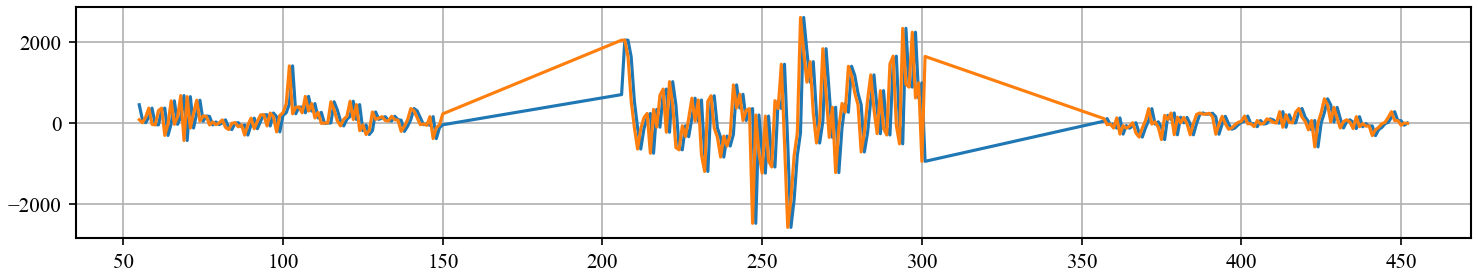

In [56]:
prep['lag1'].plot()
prep['y'].plot()
# df_train['y'].plot()

пропуски связаны с использованием 52 сезонной производной

##### список переменных

In [57]:
fcst.ts.features_order_

['unique_id',
 'temperature',
 'radiation_direct_horizontal',
 'lag1',
 'lag2',
 'lag3',
 'rolling52_lag1',
 'expanding_mean_lag2',
 'week',
 'month',
 'week_holidays',
 'date2sin',
 'date2cos']

##### Корреляция 

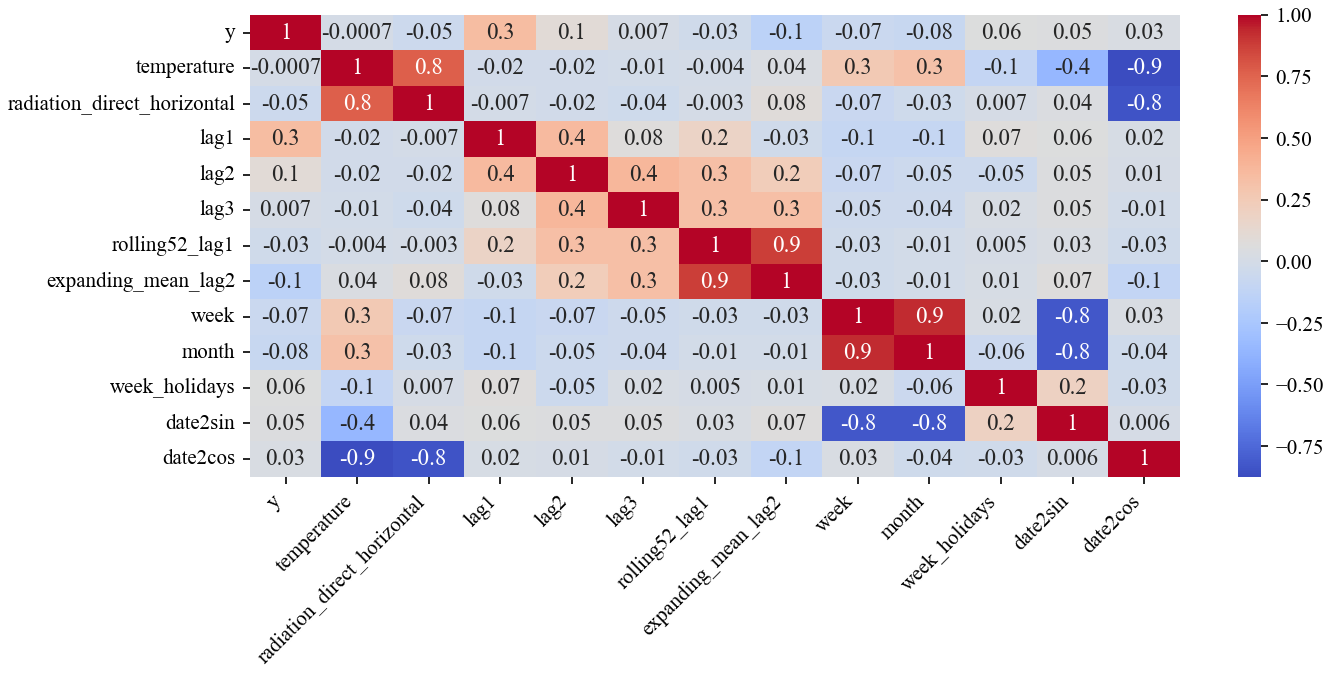

In [59]:
import seaborn as sns
plt.figure(figsize=(10, 4))
sns.heatmap(prep.drop(columns=['unique_id','ds']).corr(), annot=True, fmt='.1g', cmap="coolwarm");
plt.xticks(rotation=45, ha='right')
plt.show()


#### Оценка эффективности 

##### Чистый ВР

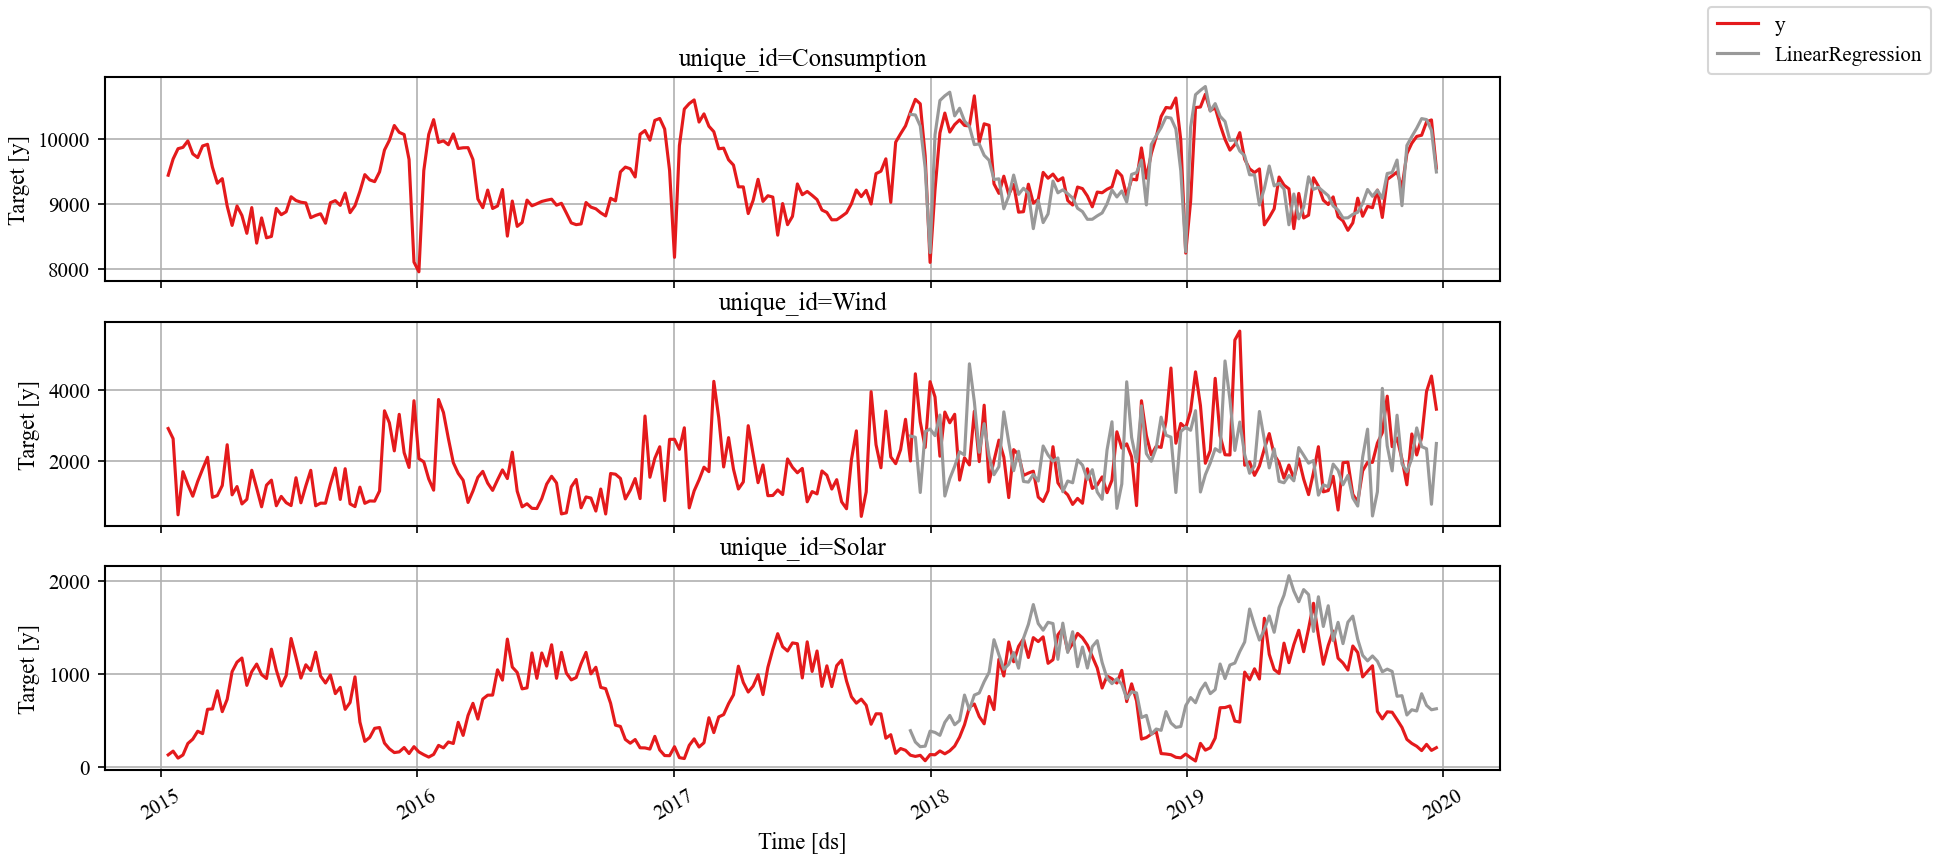

In [60]:
fcst.fit(df_train)

fcst_sf = fcst.predict(h=FH, )

evaluate_and_plot(df_train,
                  df_test,
                  forecasts_or_eval = fcst_sf,
                  metrics = metrics,)

##### ВР с экзогенными переменными

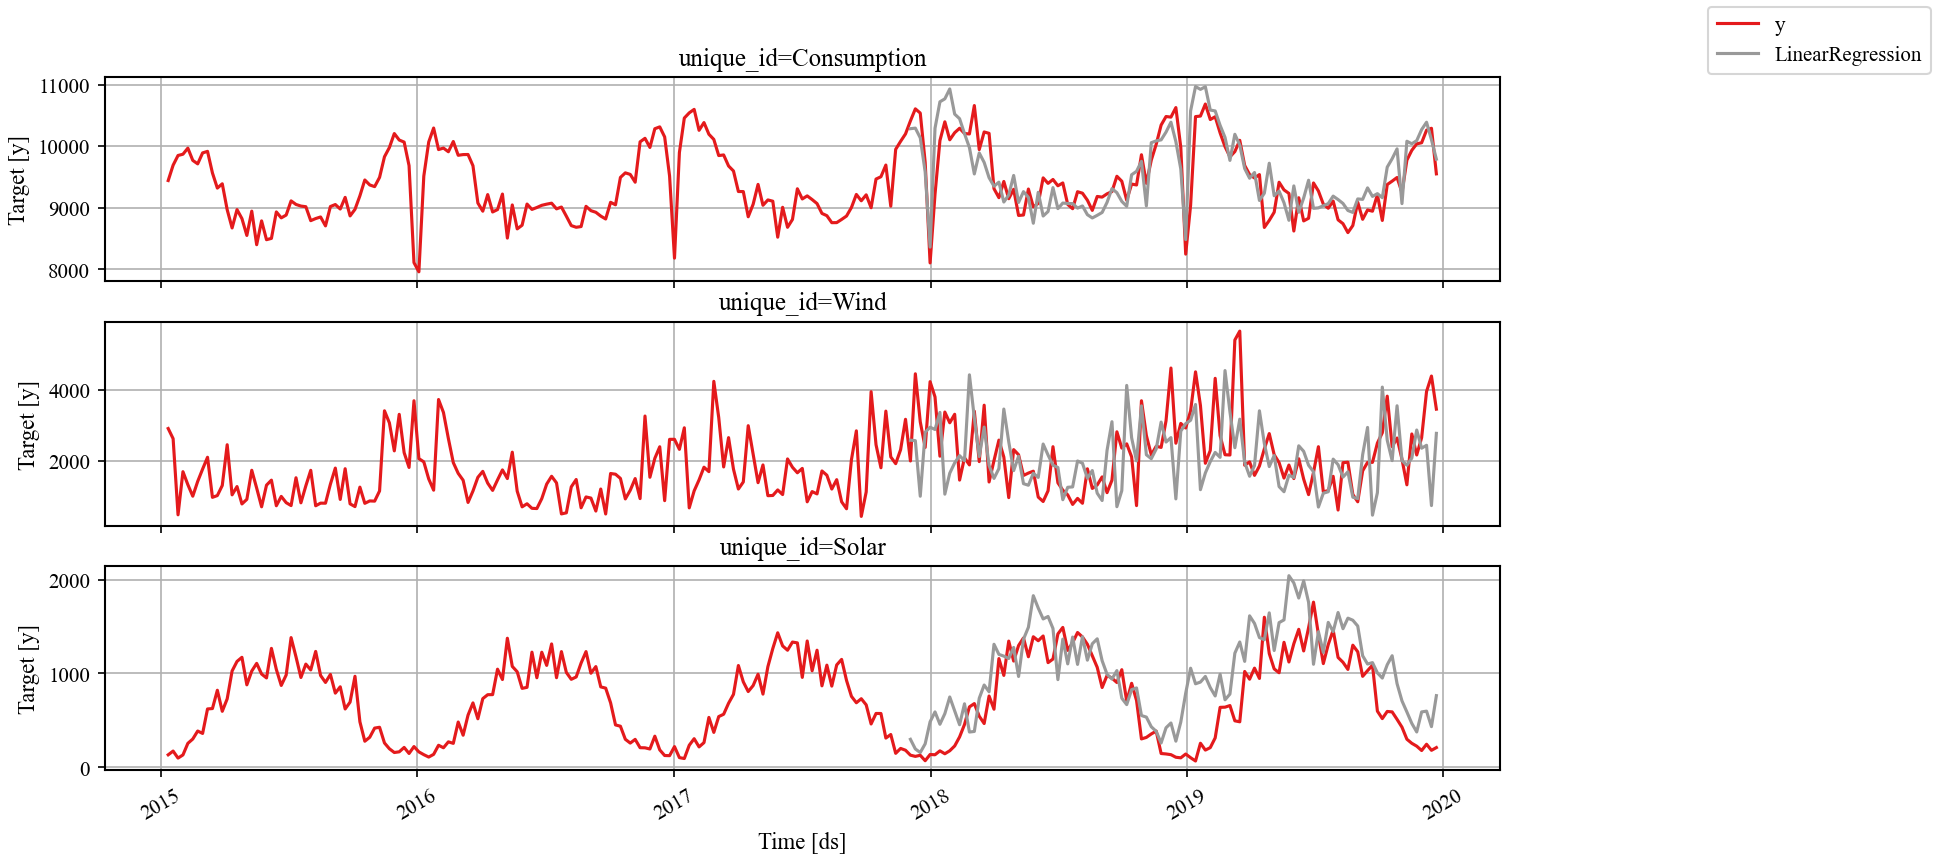

In [62]:
fcst.fit(df_train_exdogs, static_features=[])

fcst_sf = fcst.predict(h=FH, X_df = X_test )

evaluate_and_plot(df_train,
                  df_test,
                  forecasts_or_eval = fcst_sf,
                  metrics = metrics,)

#### Кастомизация интерфейса (Дополнительно):

##### Получение массивов X и y
на самом деле на отдельных этапах можно разбирать объект MLForecast и использовать по отдельности его части 

Выберем 

In [63]:
X, y = fcst.preprocess(df_train, return_X_y=True, as_numpy = False)
fcst.fit_models(X, y)

MLForecast(models=[LinearRegression], freq=<Week: weekday=6>, lag_features=['lag1', 'lag2', 'lag3', 'rolling52_lag1', 'expanding_mean_lag2'], date_features=['week', 'month', <function week_holidays at 0x0000029804915BC0>, <function date2sin at 0x0000029804915EE0>, <function date2cos at 0x0000029804916020>], num_threads=1)

##### дополнительные модели

In [64]:
from sklearn.base import BaseEstimator

class Naive(BaseEstimator):
    def fit(self, X, y=None):  
        return self

    def predict(self, X):
        return X['lag1']


fcst.models['Naive'] = Naive()

fcst.fit(df_train)


MLForecast(models=[LinearRegression, Naive], freq=<Week: weekday=6>, lag_features=['lag1', 'lag2', 'lag3', 'rolling52_lag1', 'expanding_mean_lag2'], date_features=['week', 'month', <function week_holidays at 0x0000029804915BC0>, <function date2sin at 0x0000029804915EE0>, <function date2cos at 0x0000029804916020>], num_threads=1)

##### Добавлением модели в готовый объект

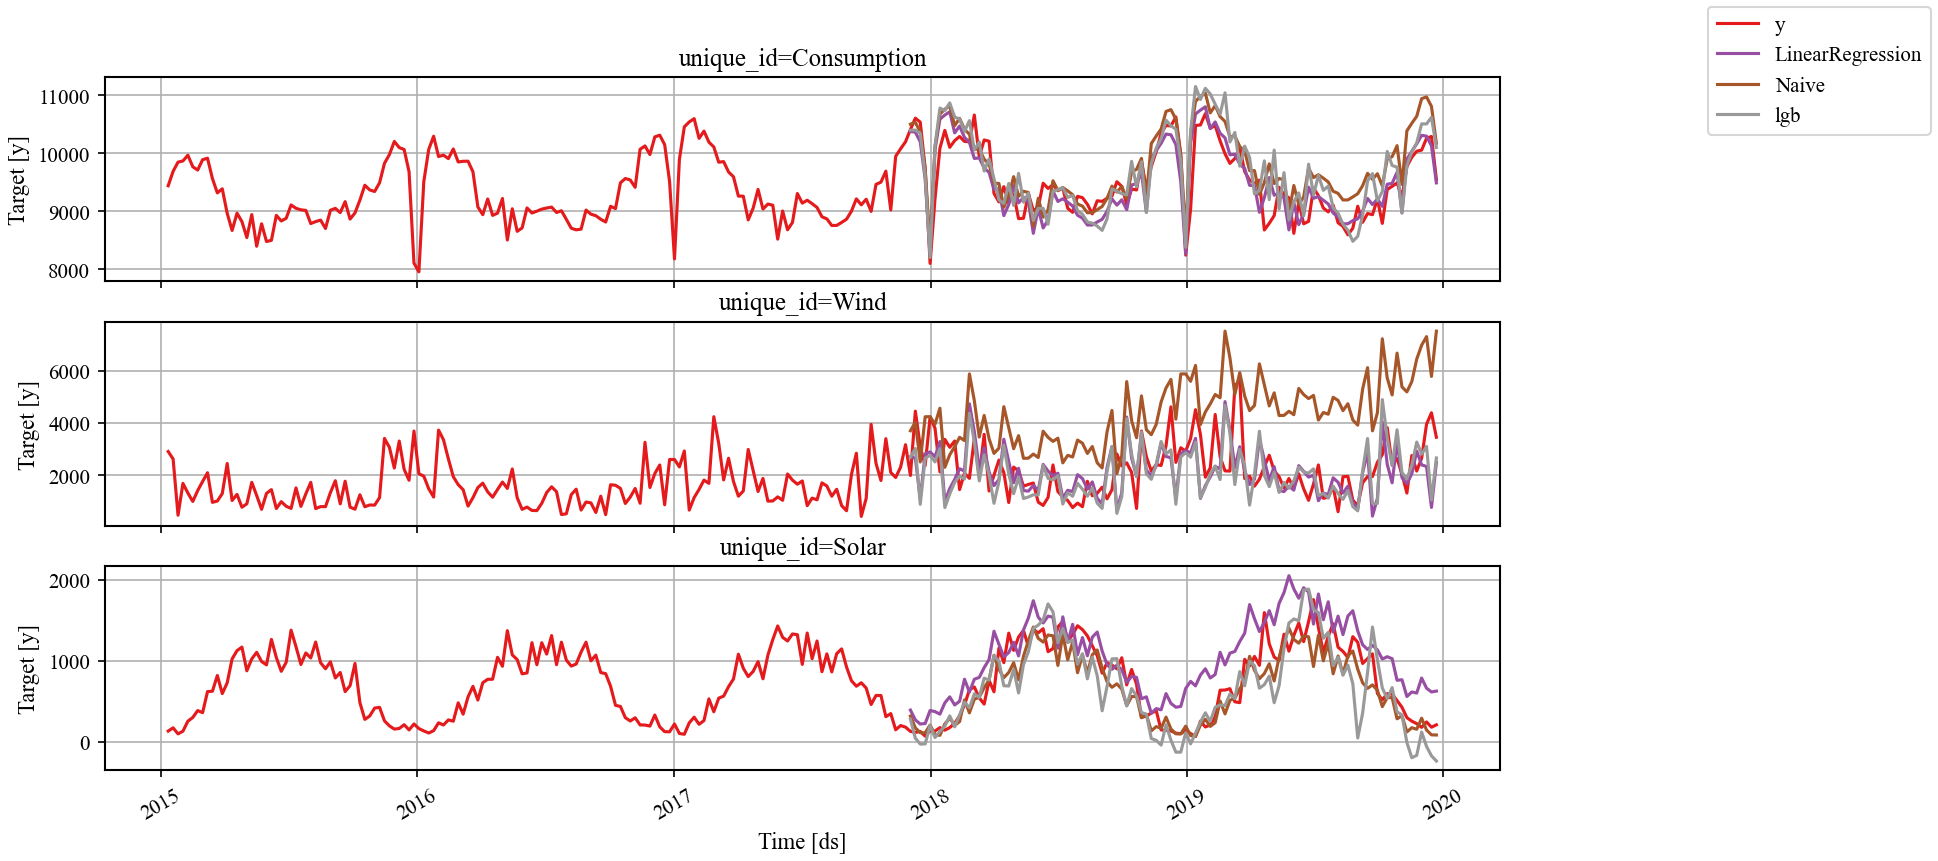

In [65]:
from lightgbm import LGBMRegressor
lgb = LGBMRegressor(verbosity=-1).fit(X, y)
fcst.models_['lgb'] = lgb
fcst_sf = fcst.predict(FH)
evaluate_and_plot(df_train,
                  df_test,
                  forecasts_or_eval = fcst_sf,
                  metrics = metrics,)

#### Упражнения
1. Провести анализ валияния отбора признаков на результат

## Обучение модели `MLForecast`

### Разница рекурсивного и прямого методов предсказания 

#### Прямое предсказание

Перейдем к исползованию `MLForecast` для предсказания. По умолчанию в `MLForecast` используется [рекурсивный ( авторегрессионный метод)](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/one_model_per_horizon.html). Этот метод предполагает предсказания горизонта [по одному шагу за раз](https://forecastegy.com/posts/multiple-time-series-forecasting-with-scikit-learn/#recursive-vs-direct-forecasting).

<!-- Для обучения моделей, сформированных преобразованиями используется метод `MLForecast.fit`. Для этого метода задаются модели  в параметре `models`. Модели могут быть заданы:
* в виде списка (в котором они будут названы с помощью имени класса и индекса, если классы повторяются) 
* в виде словаря, где ключи - это имена, которые вы хотите дать моделям, то есть имя столбца, в котором будут храниться их предсказания. 
Попробуем обучить несколько моделей 
<!-- одного класса `LightGradientBoosting`. --> 





<!-- <quote>
Напомним, что существует как минимум 3 различных способа построения прогнозов при использовании машинного обучения для временных рядов.

Чтобы понять этот метод, представьте временной ряд, содержащий всего 10 наблюдений, и модель, обученную прогнозировать только на 1 шаг вперед.

Чтобы получить прогнозы на несколько периодов, мы добавим предсказание следующего шага в исходный ряд, как если бы это была новая выборка, и используем модель для прогнозирования следующего периода.

Мы повторяем эти шаги для следующих периодов, пока не получим прогнозы на весь горизонт, который хотим предсказать. -->
Рекурсивный метод быстрее остальные в обучении, особенно если у вас большой горизонт прогнозирования. Однако, в качестве альтернативы [можно использовать прямой метод](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/one_model_per_horizon.html), при котором для каждого шага горизонта прогнозирования строится отдельная, индивидуальная модель. Чтобы использовать прямой метод в `MLForecast`, просто передайте аргумент `max_horizon` в методе `fit` с количеством периодов, которые вы хотите предсказать.
>Важно понимать, что без тестирования невозможно определить, какой метод лучше, поэтому, если вам нужна наилучшая производительность, даже если вычислительные затраты высоки, тестируйте оба метода.

<!-- Таким образом, если мы хотим предсказать 10 периодов, мы обучаем 10 моделей, каждая из которых будет предсказывать определенный шаг.
 -->




 

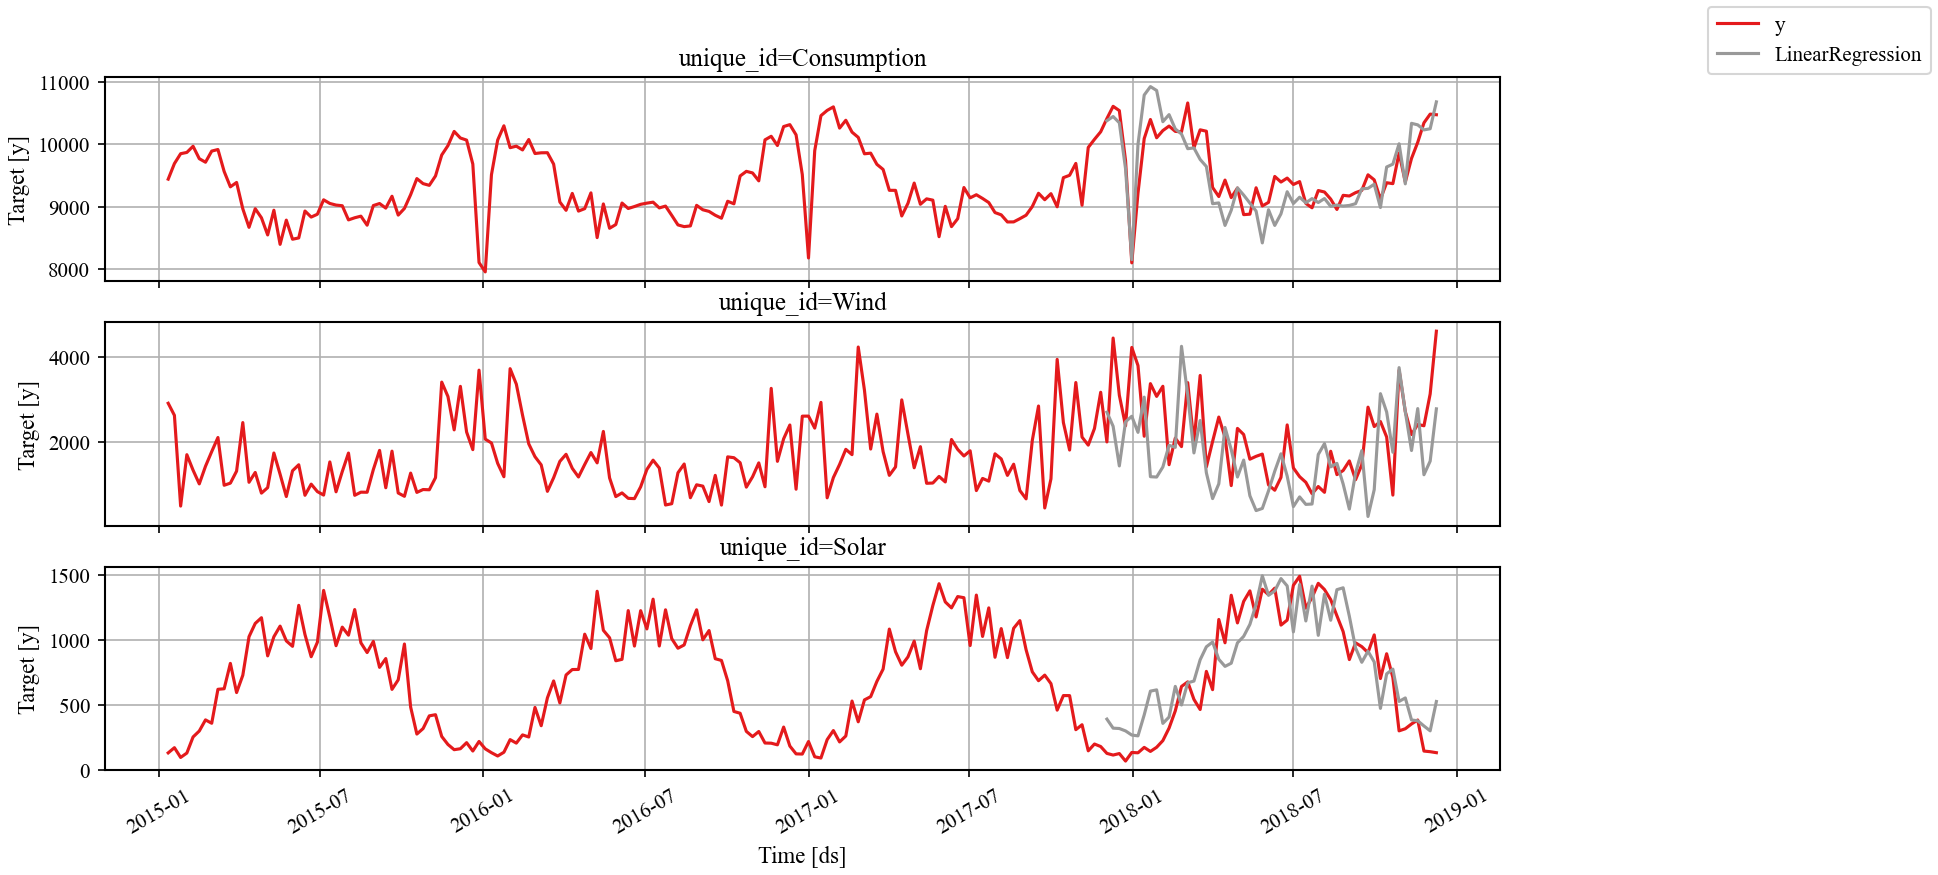

In [70]:
fcst = MLForecast(
    models=[LinearRegression()],
    lags = lags,
    freq=FREQ,
    target_transforms=target_transforms,  
    date_features = date_features,
    lag_transforms=lag_transforms,
)
fcst.fit(df_train, max_horizon = FH//2)
fcst_sf = fcst.predict(FH//2)

evaluate_and_plot(df_train,
                  df_test,
                  forecasts_or_eval = fcst_sf,
                  metrics = metrics,)

#### Рекурсивное предсказание

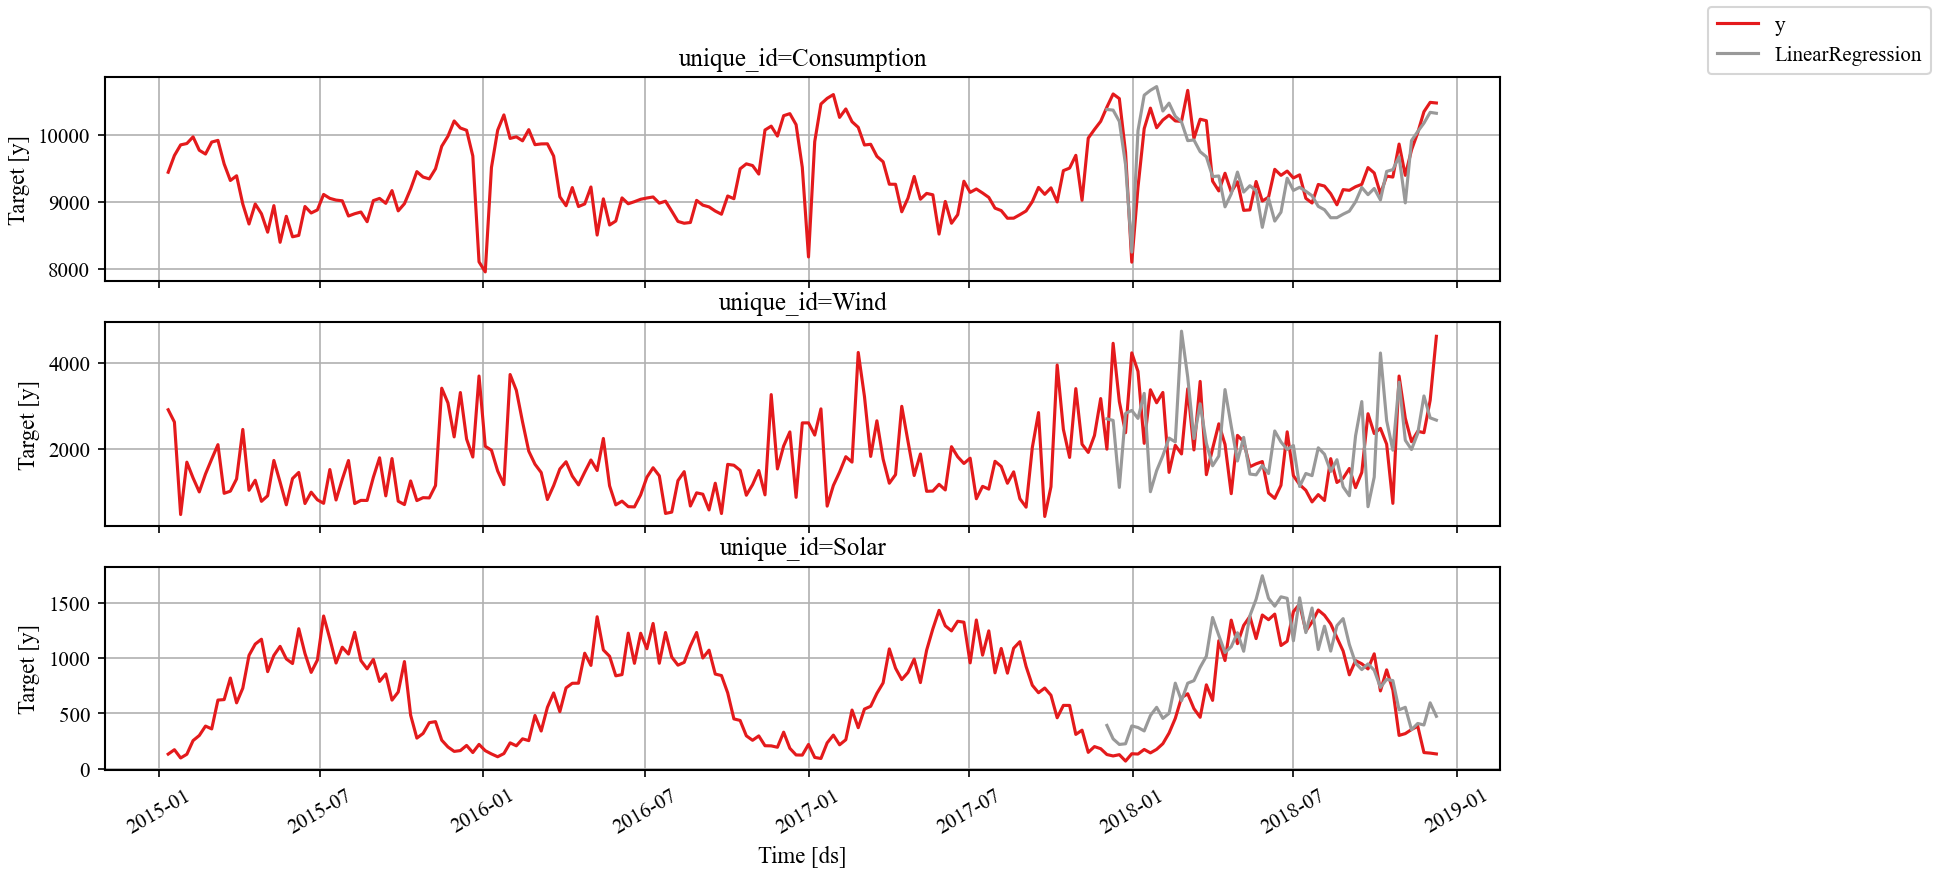

In [71]:
fcst = MLForecast(
    models=[LinearRegression()],
    lags = lags,
    freq=FREQ,
    target_transforms=target_transforms,  
    date_features = date_features,
    lag_transforms=lag_transforms,
)
fcst.fit(df_train,)
fcst_sf = fcst.predict(FH//2)

evaluate_and_plot(df_train,
                  df_test,
                  forecasts_or_eval = fcst_sf,
                  metrics = metrics,)

#### Использование интервальных оценок


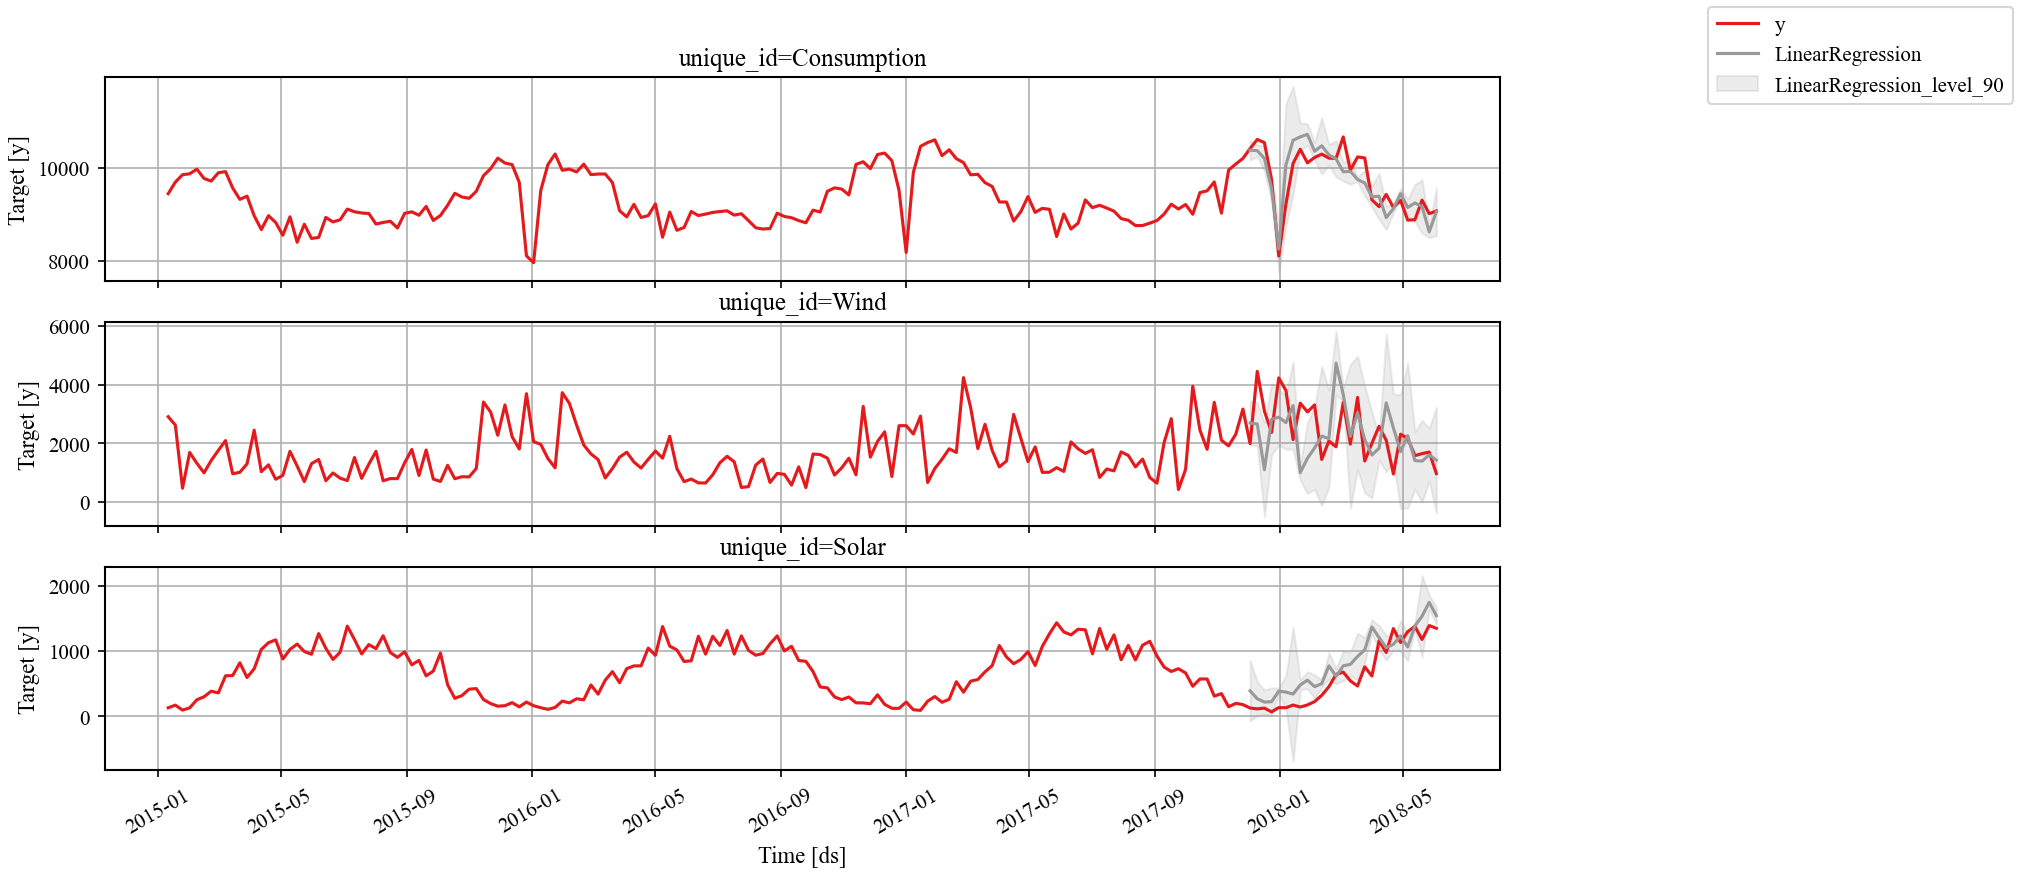

In [75]:
prediction_intervals=PredictionIntervals(n_windows=2, h=FH//4)

fcst = MLForecast(
    models=[LinearRegression()],
    lags = lags,
    freq=FREQ,
    target_transforms=target_transforms,  
    date_features = date_features,
    lag_transforms=lag_transforms,
)
fcst.fit(df_train,
         prediction_intervals = prediction_intervals
        )
fcst_sf = fcst.predict(FH//4,
                      level = [90])

evaluate_and_plot(df_train,
                  df_test,
                  forecasts_or_eval = fcst_sf,
                  levels = [90],
                  metrics = metrics + [coverage],)

#### Кросс-валидация

In [76]:
model_names = fcst.models_
model_names = list(model_names.keys())

cv_conf = dict(h=FH//4,
           n_windows=8,
           step_size=FH//16, 
           refit=True,  ) 

cv_df = fcst.cross_validation(
    df=panel_df,
    static_features = [],
    **cv_conf
)

In [77]:
df_results = evaluate(
    cv_df,
    metrics=metrics,
    models=model_names,
    train_df=df_train,
    level=None,
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    cutoff_col="cutoff",
    agg_fn=None,
)
avg_by_series = df_results.groupby(['unique_id', 'metric']).mean(numeric_only=True)
avg_by_series.style.background_gradient(cmap='RdYlGn_r', axis=1).format(precision=2)

#### Упражнене 
1. Проверить влияние стратегий обучения и виляние экзогенных факторов на значения вероятностных метрик

### Сравнение моделей

#### модели с Scikit-learn интерфейсом

Полезной особенностью фреймворка может быть очень простой способ сравнения моделей. Как уже говорилось модели могут быть заданы при помощи словаря, как это показано ниже.

C:\Users\Ronkin\anaconda3\envs\ts\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.967e+07, tolerance: 6.844e+05
  model = cd_fast.enet_coordinate_descent(


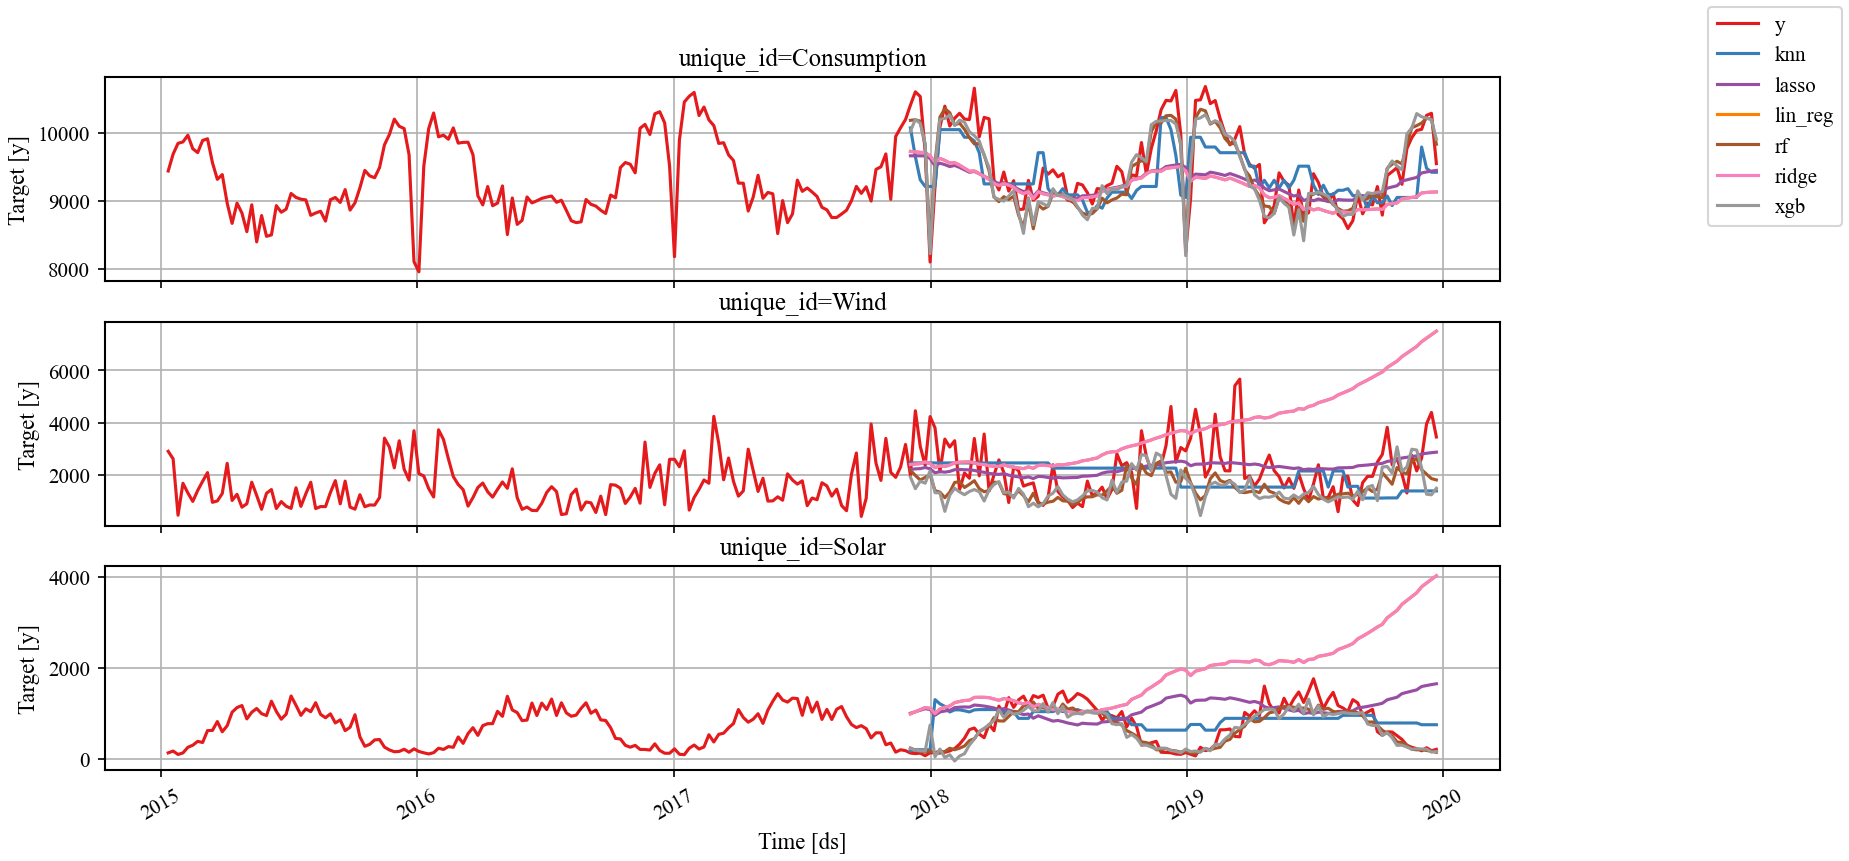

In [81]:
models={
        'lasso': Lasso(),
        'lin_reg': LinearRegression(),
        'ridge': Ridge(alpha=0.10),
        'rf': RandomForestRegressor(),
        'knn':KNeighborsRegressor(n_neighbors=3),
        'xgb':XGBRegressor()
}


fcst = MLForecast(
    models=models,
    freq=FREQ,
    target_transforms=None,  
    date_features = date_features,
    lag_transforms=lag_transforms,
)
fcst.fit(df_train,)
fcst_sf = fcst.predict(FH)

evaluate_and_plot(df_train,
                  df_test,
                  forecasts_or_eval = fcst_sf,
                  metrics = metrics,)

#### Добавление пайплайна scikit-learn  к обучению моделей

По мимо размещения моделей предсказания как таковых могут быть созданы [пайплайны предсказания](https://forecastegy.com/posts/multivariate-time-series-forecasting-in-python/). Создадим такой пайплайн с использованием стандартизации признаков и их отбора методом PCA.

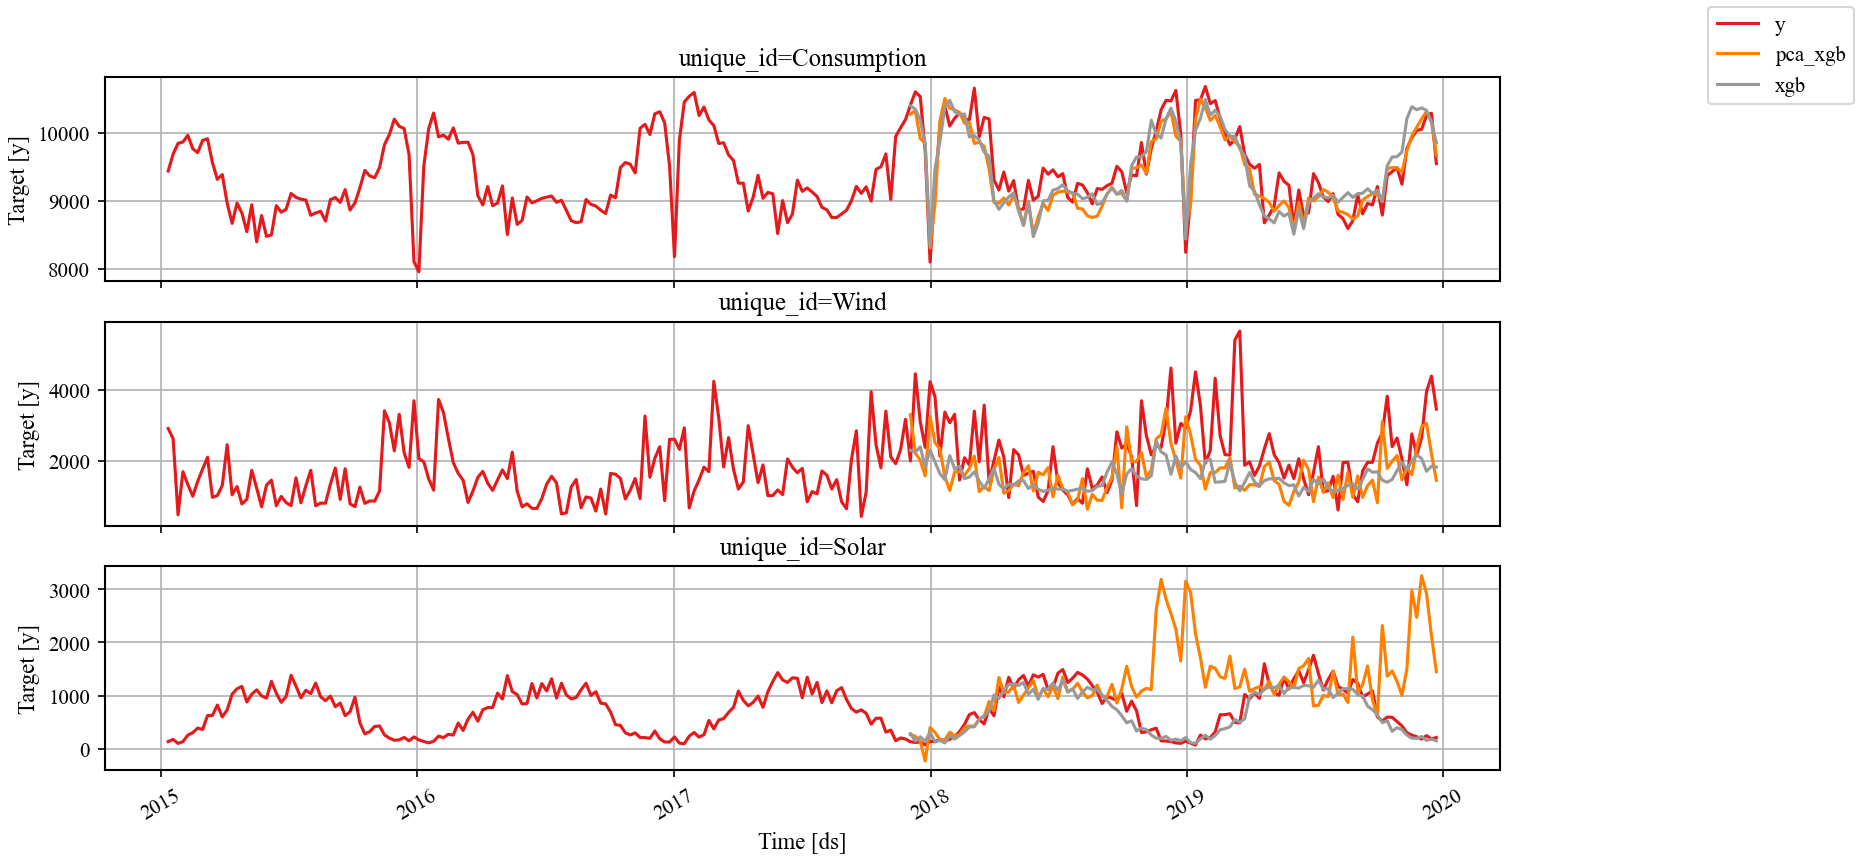

In [87]:
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler

models = {'pca_xgb': make_pipeline (StandardScaler(),
                                      PCA(n_components=5), 
                                      XGBRegressor()),
         'xgb': make_pipeline (MinMaxScaler(),
                               XGBRegressor())}

fcst = MLForecast(
    models=models,
    lags = lags,
    freq=FREQ,
    target_transforms=None,  
    date_features = date_features,
    lag_transforms=lag_transforms,
)
fcst.fit(df_train)
fcst_sf = fcst.predict(FH)


evaluate_and_plot(df_train,
                  df_test,
                  forecasts_or_eval = fcst_sf,
                  metrics = metrics,)

#### Кодирование признаков

<!-- Также отметим, что для категориальных признаков важно бы было их кодирование. В нескотором смысле  -->
Признаки дат можно считать категориальными. 
<!-- Мы уже увидили, что иногда можно заменять такие призаких их т.н. [`target encoding`](https://letsdatascience.com/target-encoding/). В нелинейных можно бы было оставить признак квартал год без изменений - фактически используя [Label encoding](https://scikit-learn.org/stable/modules/preprocessing_targets.html). Однако  -->
В линейных моделях такие признраки рекомендуется кодировать
<!-- <!-- Так как модели чувствительны к значениям. Покажем как можно кодировать такие признаки  -->
при помощи  [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html). 
Для этого [задействуем `ColumnTransformer` из библиотеки `sklearn`](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/sklearn_pipelines.html).

In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder

ohe = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first'), ['month',]),
        ('te', TargetEncoder(), ['week'])
    ],
    remainder='passthrough',
)


models = {'pca_lasso': make_pipeline (StandardScaler(),
                                      PCA(n_components=5), 
                                      Lasso()),
          
          'ohe_lasso': make_pipeline (ohe,
                                      StandardScaler(),
                                      # PCA(n_components=5),
                                      Lasso()),  
          
         'lin_reg': make_pipeline (StandardScaler(),LinearRegression())}

fcst = MLForecast(
    models=models,
    lags = lags,
    freq=FREQ,
    target_transforms=target_transforms,  
    date_features = date_features,
    lag_transforms=lag_transforms,
)



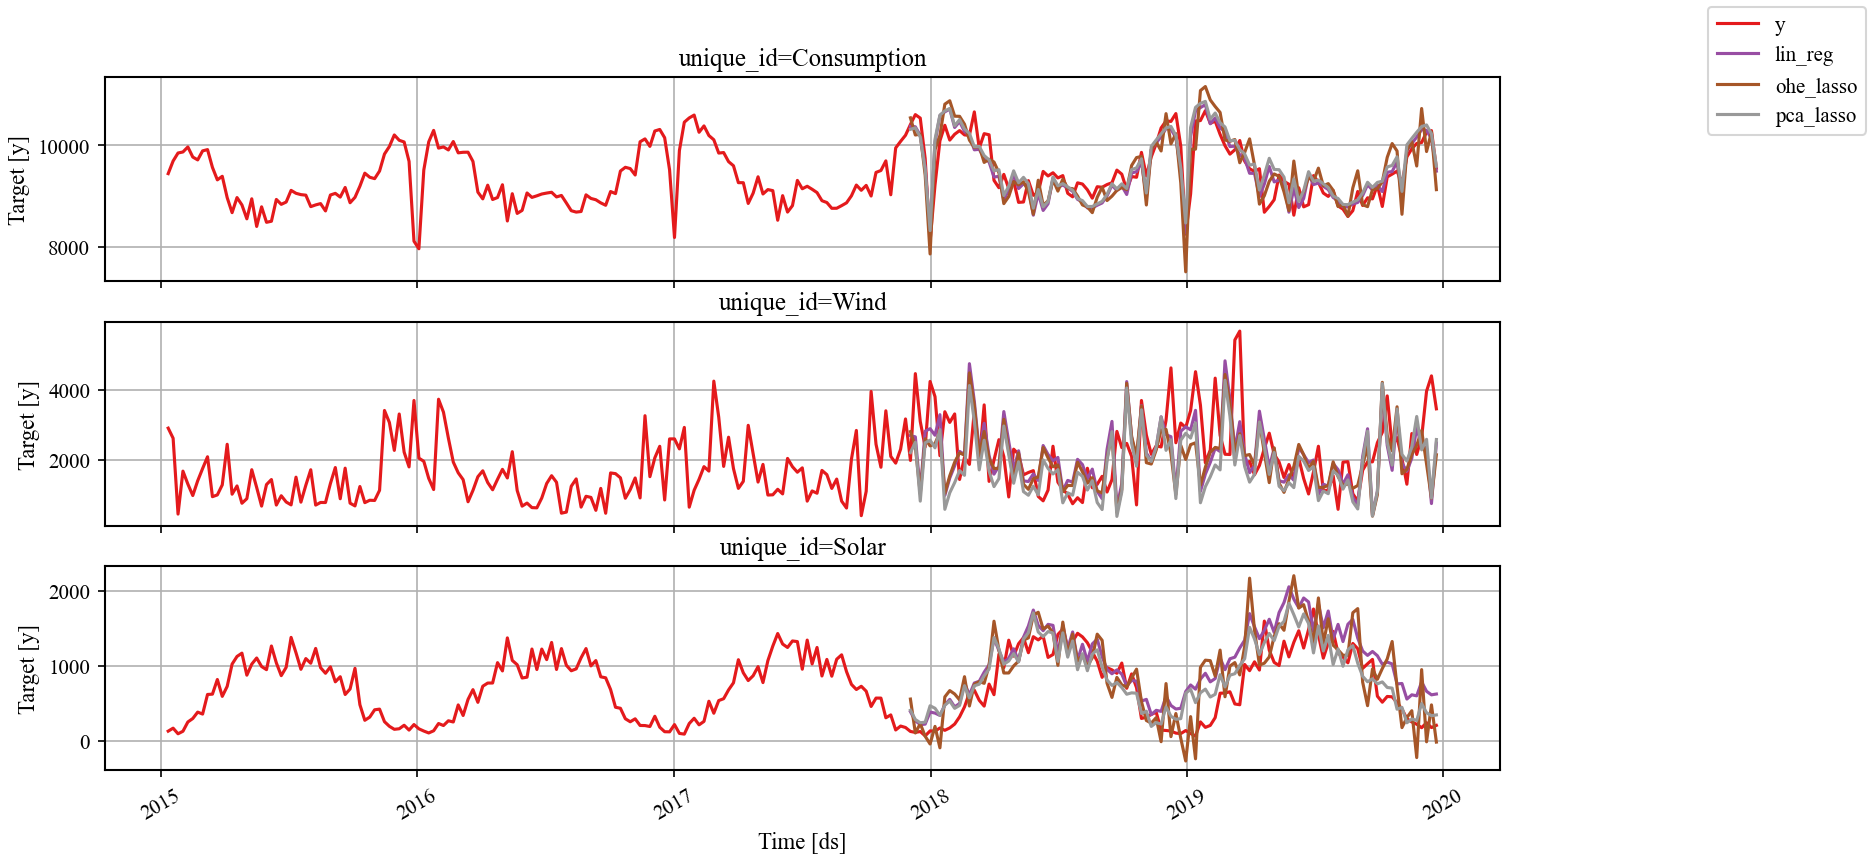

In [89]:
fcst.fit(df_train,)
fcst_sf = fcst.predict(FH)

evaluate_and_plot(df_train,
                  df_test,
                  forecasts_or_eval = fcst_sf,
                  metrics = metrics,)

#### Упражнения
1. Проверить качество прогнозов при помощи ML методов с шагом в 1 день.
2. 

## Интерпретация признаков

### permutation importance

Обычно Lag1 (предыдущее значение) самый важный. Если важны Month или DayOfWeek — есть сезонность.


In [90]:
from sklearn.inspection import permutation_importance

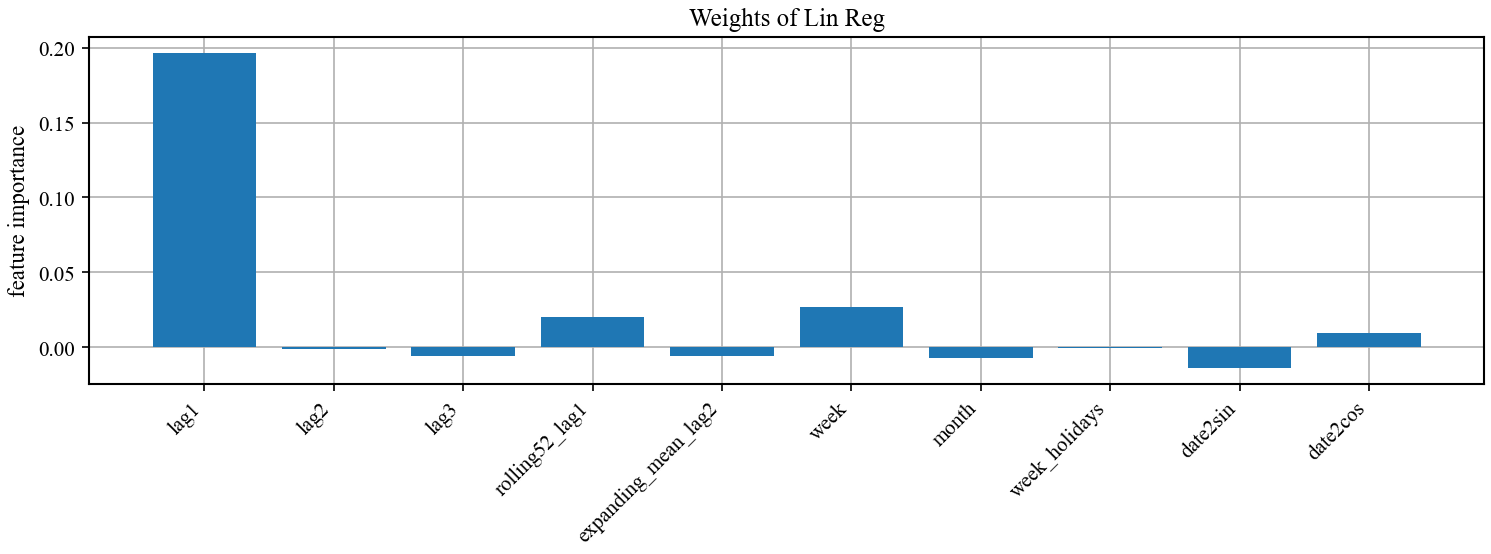

In [91]:
X, y = fcst.preprocess(df_train, return_X_y=True, as_numpy=False)

X_train, y_train,  X_val, y_val = X.iloc[:-FH,:], y[:-FH], X.iloc[FH:,:], y[FH:]

feature_names = fcst.ts.features_order_

fcst.models_['lin_reg'].fit(X_train, y_train)

result = permutation_importance(fcst.models_['lin_reg'],  X_val, y_val, n_repeats=30, random_state=42)

perm_importances = result.importances_mean

plt.figure(figsize=(12,3))
plt.bar(feature_names, perm_importances)
plt.ylabel('feature importance')
plt.title('Weights of Lin Reg')
plt.xticks(rotation=45, ha='right')
plt.show()

Наибольшее значение имеет лаг 1, а также то, выходной день или нет. В некоторым смысле это ожидаемые результаты.

### Shape

#### LinearExplainer

Также можно произвести анализ общими фреймворками

In [92]:
import shap

ModuleNotFoundError: No module named 'shap'

In [93]:
prep = fcst.preprocess(df_train)
X = prep.drop(columns=['unique_id', 'ds', 'y'])
X50 = shap.utils.sample(X, 50)

NameError: name 'shap' is not defined

In [69]:
# 1. Получаем данные, которые видит модель (с лагами)
prep = fcst.preprocess(df_train)
feature_cols = [c for c in prep.columns if c not in ['unique_id', 'ds', 'y']]
X = prep[feature_cols]

# 2. Масштабируем данные (как в пайплайне)
# Важно: берем scaler из обученного пайплайна
model_pipeline = fcst.models_['lin_reg']
scaler = model_pipeline.named_steps['standardscaler']
linear_model = model_pipeline.named_steps['linearregression']

X_scaled = scaler.transform(X)
# ВОЗВРАЩАЕМ ИМЕНА СТОЛБЦОВ!
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)

# 3. Выбираем фоновые данные (background data) для SHAP
# Для временных рядов лучше брать случайные отрезки, а не просто первые строки
X50 = X_scaled_df.sample(50, random_state=42)

# 4. Инициализируем Explainer
# Передаем имена признаков явно, если используем массив, или DataFrame (новая версия SHAP)
explainer = shap.LinearExplainer(linear_model, X50, feature_names=feature_cols)

# 5. Считаем SHAP значения
shap_values = explainer(X_scaled_df)

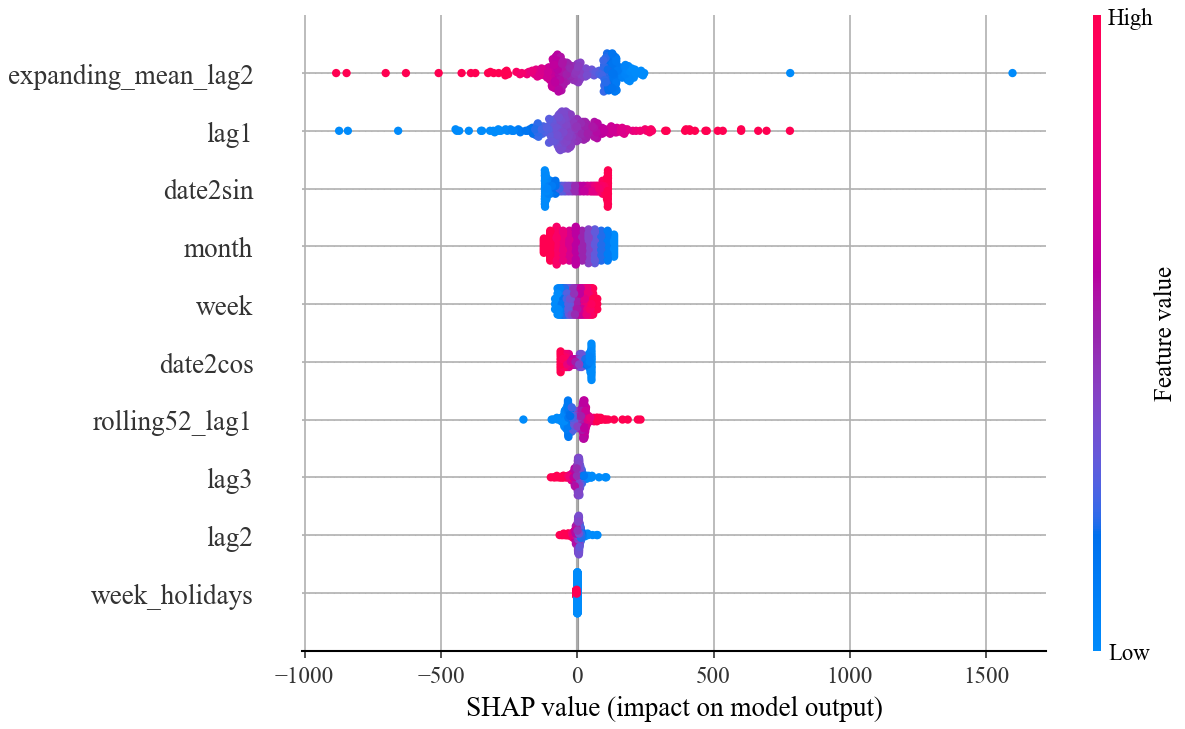

In [75]:
shap.plots.beeswarm(shap_values)

- Ось Y: Признаки (features), отсортированные по важности (сверху самые важные).
- Ось X: SHAP value (вклад в прогноз). Значения слева от 0 уменьшают прогноз, справа — увеличивают.
- Цвет точки: Значение признака. Красный — высокое значение, Синий — низкое значение.
- Положение точки: Каждая точка — это один конкретный пример (одна неделя в нашем случае).

Видно, что на результаты прогноза сильнее всего влияют Lag1 и месяц. Также можно отметить весьма сомнительное поведение расширяющейся части 2 лага.

#### Глобальная важность признаков

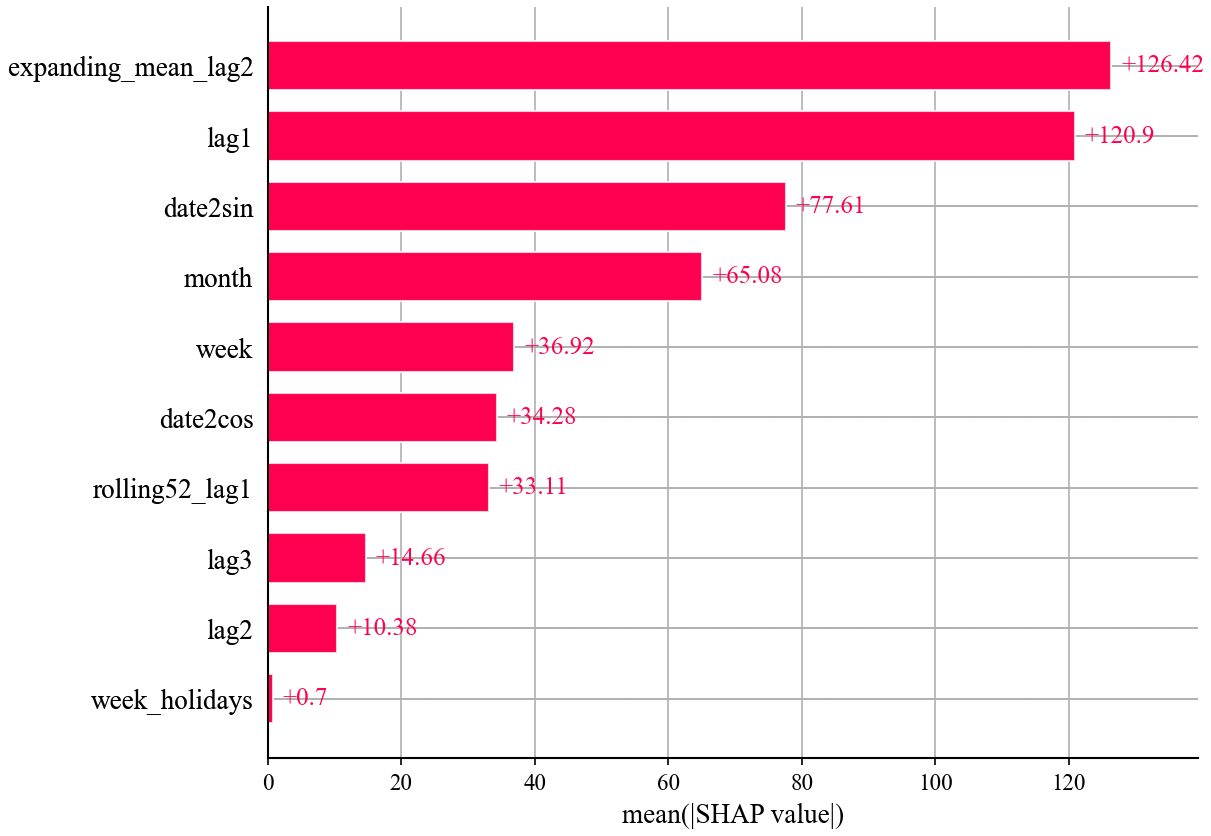

In [76]:
shap.plots.bar(shap_values)

Глобально сильнее всего на результат влияет лаг 2, однако из графика не ясно в какую сторону

#### Упражнения
1. Рассмотренные варианты анализа важности признаков не разделяют ВР внутри датасета. Предлагается проверить важность признаков для каждой переменной отдельно.
2. Проведите анализ важности признаков с учетом экзогенных факторов.
3. Проведите эксперменты с пространством признаков, проанализировав их важность.

In [94]:
import session_info

In [95]:
session_info.show()

C:\Users\Ronkin\anaconda3\envs\ts\Lib\site-packages\session_info\main.py:213: DeprecationWarning: Accessing jsonschema.__version__ is deprecated and will be removed in a future release. Use importlib.metadata directly to query for jsonschema's version.
  mod_version = _find_version(mod.__version__)
C:\Users\Ronkin\anaconda3\envs\ts\Lib\site-packages\session_info\main.py:213: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


## Дополнительно

#### Автотюнинг 

В конце раздела также скажем о возможности использования сторонней оптимизации для  поиска гиперпараметров моделей в рамках `mlforecast`. В данном [примере](https://forecastegy.com/posts/multiple-time-series-forecasting-with-lightgbm-in-python/) мы попробуем подобрать параметры модели  `Lasso` и последний лаг в объекте при помощи популярной библиотеки [`optuna`](https://optuna.org/). Для этого опишим объект оптимизации и т.н. [`trail`](https://github.com/optuna/optuna/blob/master/README.md#key-features) для оптимизируемых параметров. 

In [107]:
import optuna
from sklearn.metrics import mean_absolute_percentage_error
def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 1e-0, step=1e-3)
    selection = trial.suggest_categorical('selection ', ['cyclic', 'random'])
    
    last_lag = trial.suggest_int('llag', 13, 52, step=13)

    models = [Lasso(alpha=alpha,selection=selection) ]
    
    model = MLForecast(
                    models=models,
                    freq=FREQ,
                    lags=[1,2, last_lag],
                    target_transforms=target_transforms,
                    date_features = date_features,
                    lag_transforms={1: [(rolling_max, 7)]},
                    num_threads=6)


    model.fit(df_train, id_col='unique_id', time_col='ds', target_col='y')

    preds = model.predict(FH)
    
    preds = preds.merge(df_test[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')

    error = mean_absolute_percentage_error(preds['y'], preds['Lasso'])
    
    return error


# plot_series(df, preds, palette='tab20b')

Теперь создадим процесс оптимизации и запустим его. После чего посмотрим на лучшие результаты.

In [108]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)
study.best_params

[I 2026-03-03 18:33:57,697] A new study created in memory with name: no-name-0c6cd501-d5ed-4a78-898d-36bd6bb46f36
[I 2026-03-03 18:33:58,327] Trial 0 finished with value: 0.29613110590798425 and parameters: {'alpha': 0.299, 'selection ': 'cyclic', 'llag': 26}. Best is trial 0 with value: 0.29613110590798425.
[I 2026-03-03 18:33:58,936] Trial 1 finished with value: 0.28121880975235336 and parameters: {'alpha': 0.359, 'selection ': 'random', 'llag': 13}. Best is trial 1 with value: 0.28121880975235336.
C:\Users\Ronkin\anaconda3\envs\py39\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.679e+07, tolerance: 6.169e+03
  model = cd_fast.enet_coordinate_descent(
[I 2026-03-03 18:33:59,556] Trial 2 finished with value: 0.23370594062038588 and parameters: {'alpha': 0.23500000000000001, 'select

{'alpha': 0.736, 'selection ': 'random', 'llag': 52}

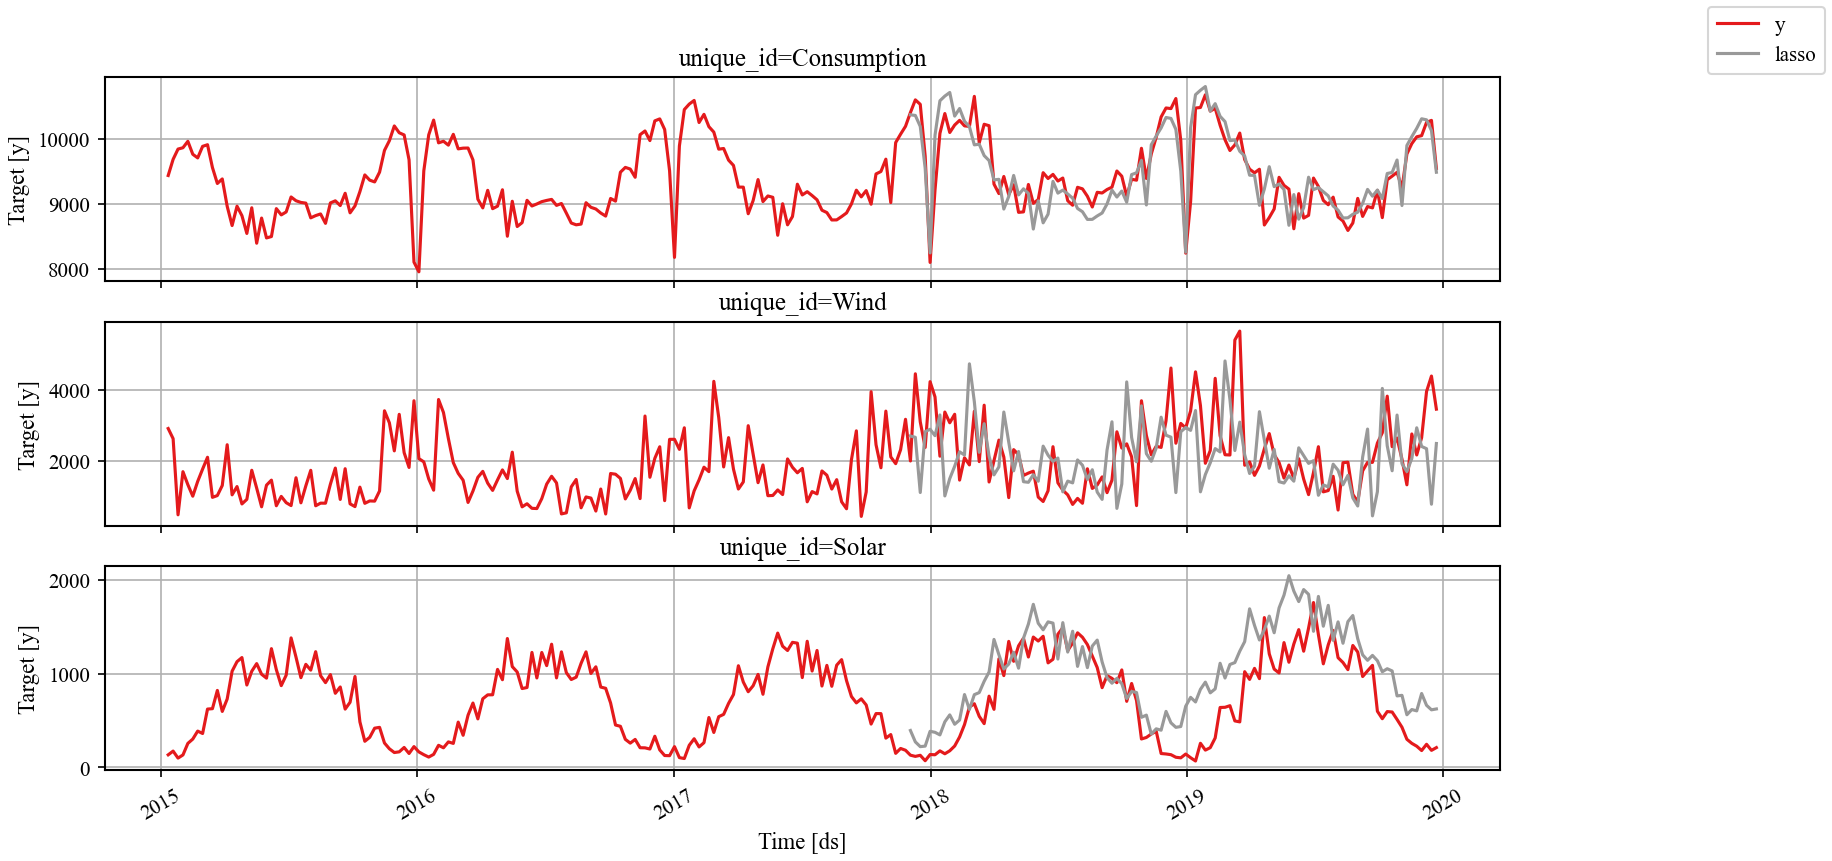

In [131]:
models={'lasso': Lasso(alpha= 0.467, selection='cyclic'),}

fcst = MLForecast(
    models=models,
    lags = lags,
    freq=FREQ,
    target_transforms=target_transforms,  
    date_features = date_features,
    lag_transforms=lag_transforms,
)
fcst.fit(df_train)
preds = fcst.predict(FH)
evaluate_and_plot(df_train,
                  df_test,
                  forecasts_or_eval = preds,
                  metrics = metrics,)

#### AutoModel

In [96]:
from mlforecast.auto import AutoLightGBM, AutoModel, AutoMLForecast, AutoCatboost, AutoRidge

In [97]:
auto_mlf = AutoMLForecast(
    freq=FREQ,
    season_length=52,
    models={'ridge': AutoRidge(), 
            'lgb':AutoLightGBM()},
)
auto_mlf.fit(
    df=df_train,
    n_windows=2,
    h=FH//4,
    num_samples=2,
    optimize_kwargs={'timeout': 60},
)
fcst = auto_mlf.predict(h=FH)

[I 2026-04-30 18:42:17,880] A new study created in memory with name: no-name-1d7b9689-e6dd-45fa-8837-f98dd2f3df05
[I 2026-04-30 18:42:17,961] Trial 0 finished with value: 0.22518531817584092 and parameters: {'fit_intercept': False, 'alpha': 6.028030997340368, 'target_transforms_idx': 4, 'lags_idx': 0, 'lag_transforms_idx': 2, 'use_date_features': 0}. Best is trial 0 with value: 0.22518531817584092.
[I 2026-04-30 18:42:18,049] Trial 1 finished with value: 0.12890864455868362 and parameters: {'fit_intercept': False, 'alpha': 7.7817893527475555, 'target_transforms_idx': 1, 'lags_idx': 1, 'lag_transforms_idx': 0, 'use_date_features': 1}. Best is trial 1 with value: 0.12890864455868362.
[I 2026-04-30 18:42:18,058] A new study created in memory with name: no-name-2f8ada7b-10c8-41bc-a5a3-a28d656aca50
[I 2026-04-30 18:42:18,219] Trial 0 finished with value: 0.4328704609582977 and parameters: {'n_estimators': 118, 'lambda_l1': 0.001305886823451577, 'lambda_l2': 1.4760742495197955e-08, 'num_leav

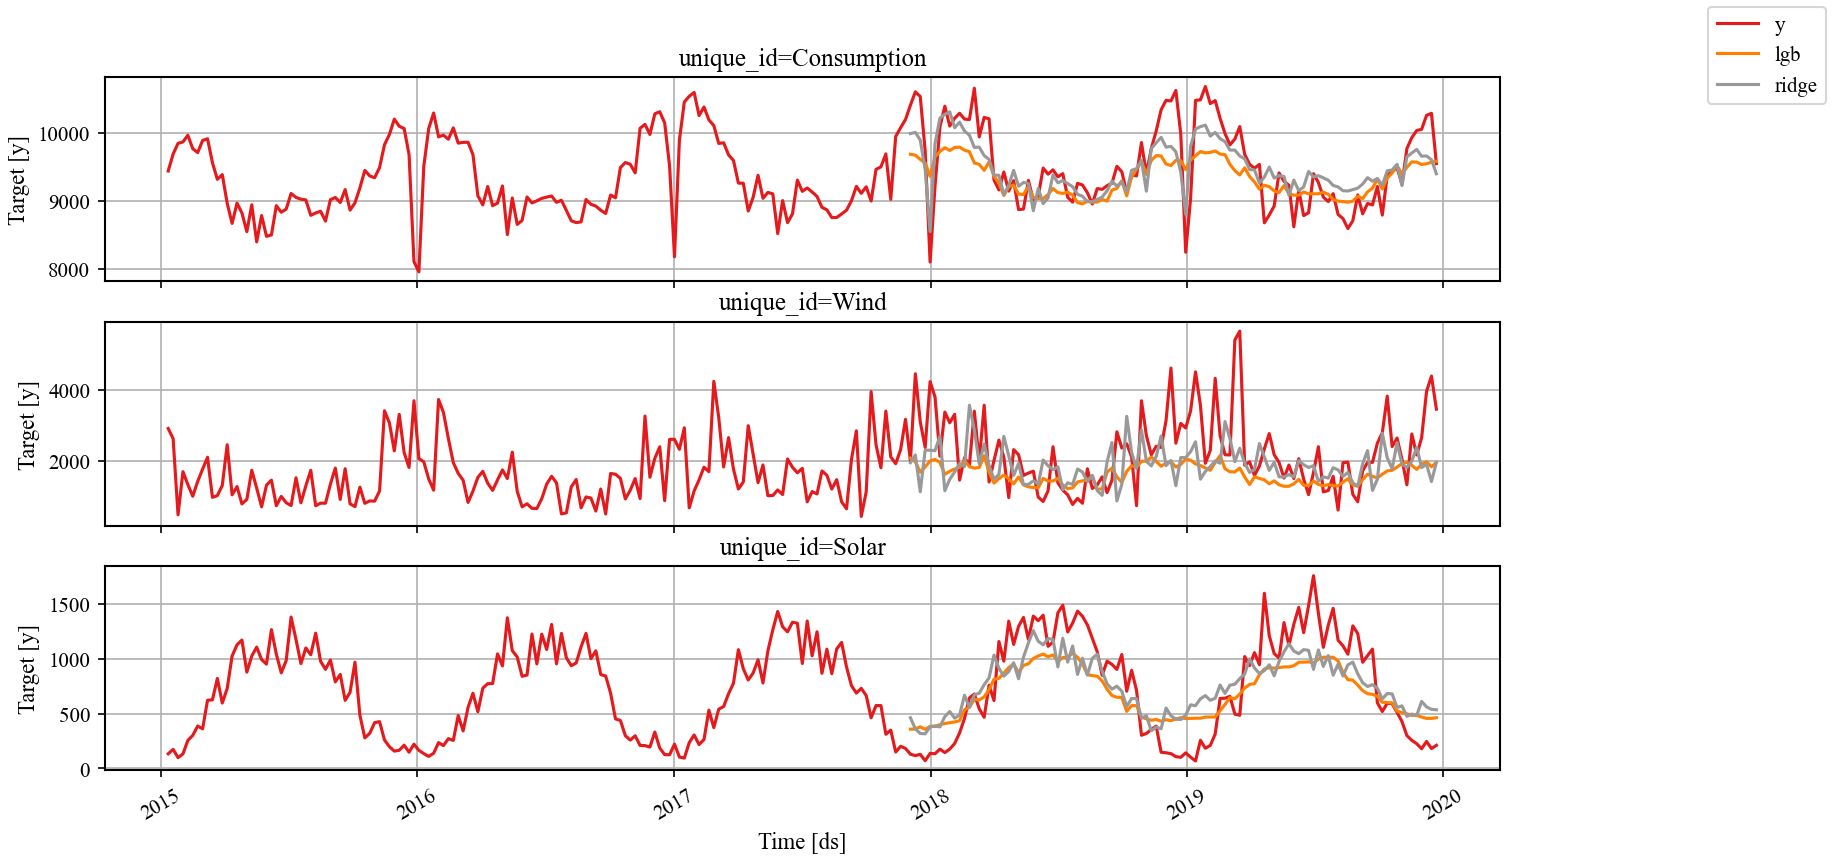

In [98]:
evaluate_and_plot(df_train,
                  df_test,
                  forecasts_or_eval = fcst,
                  metrics = metrics,)